In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =1 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 1  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 1

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c1_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c1_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

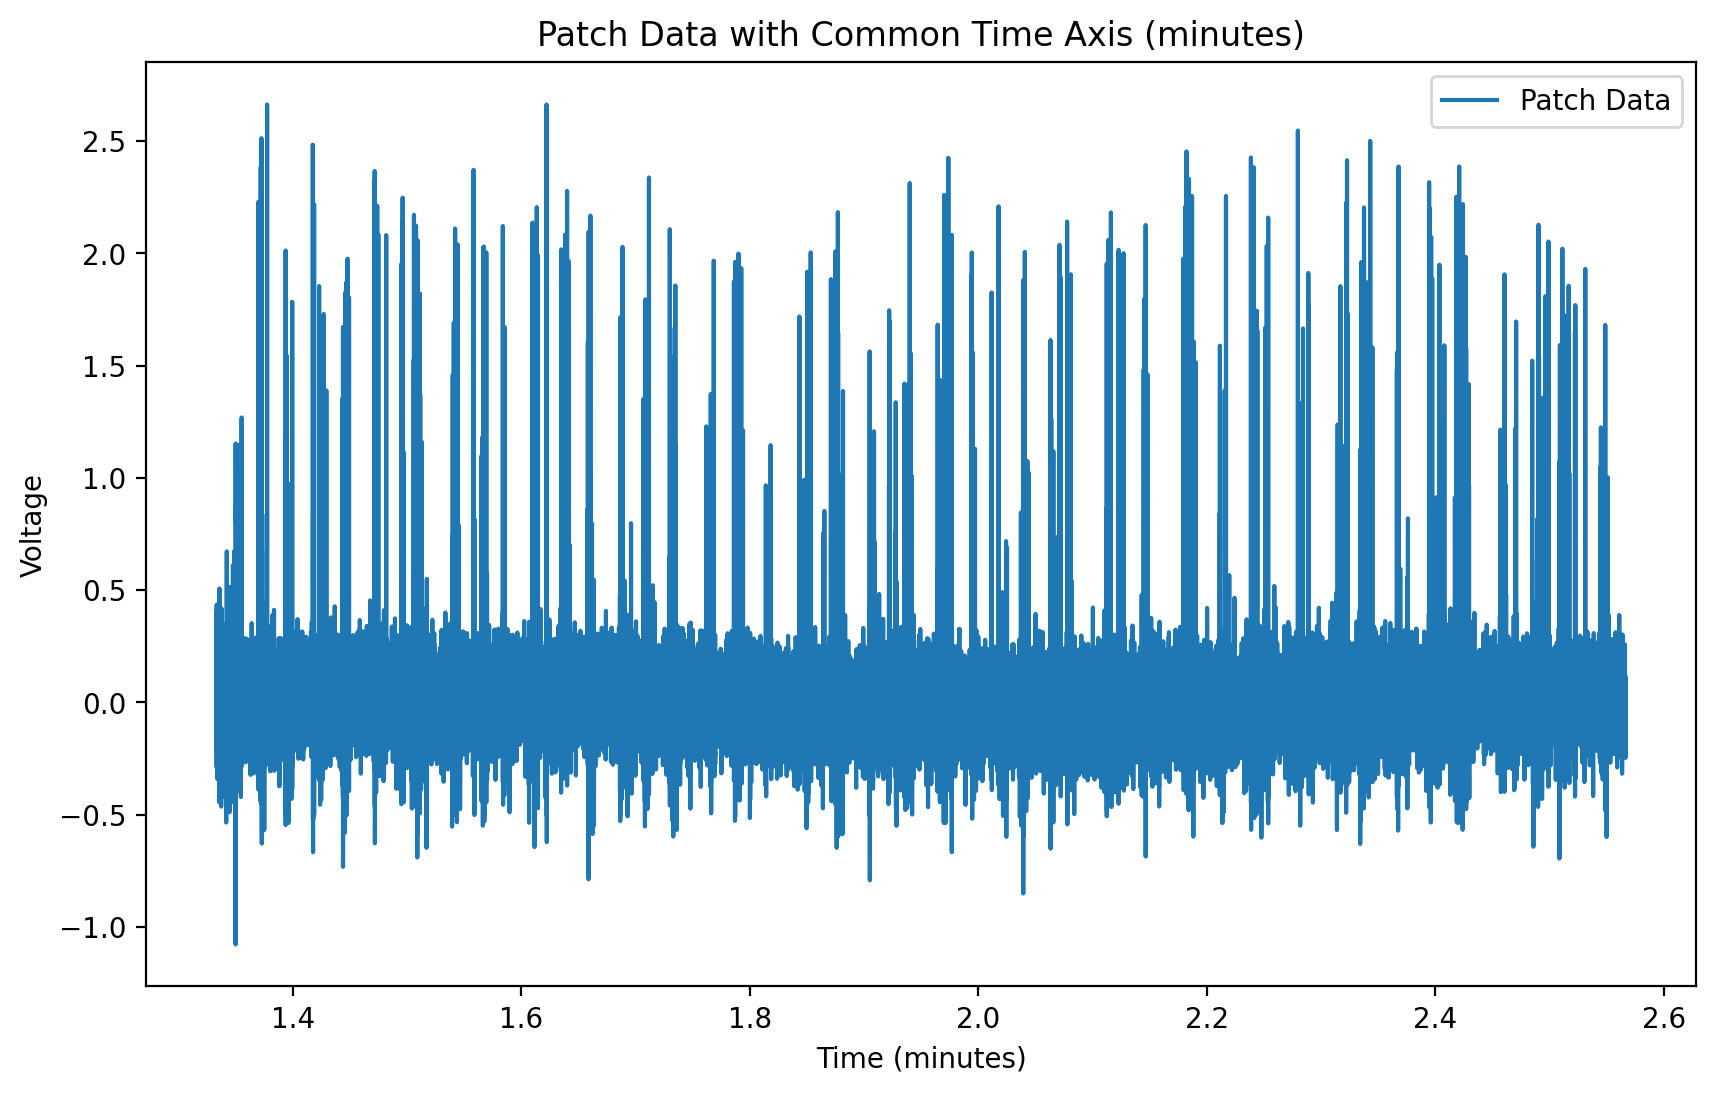

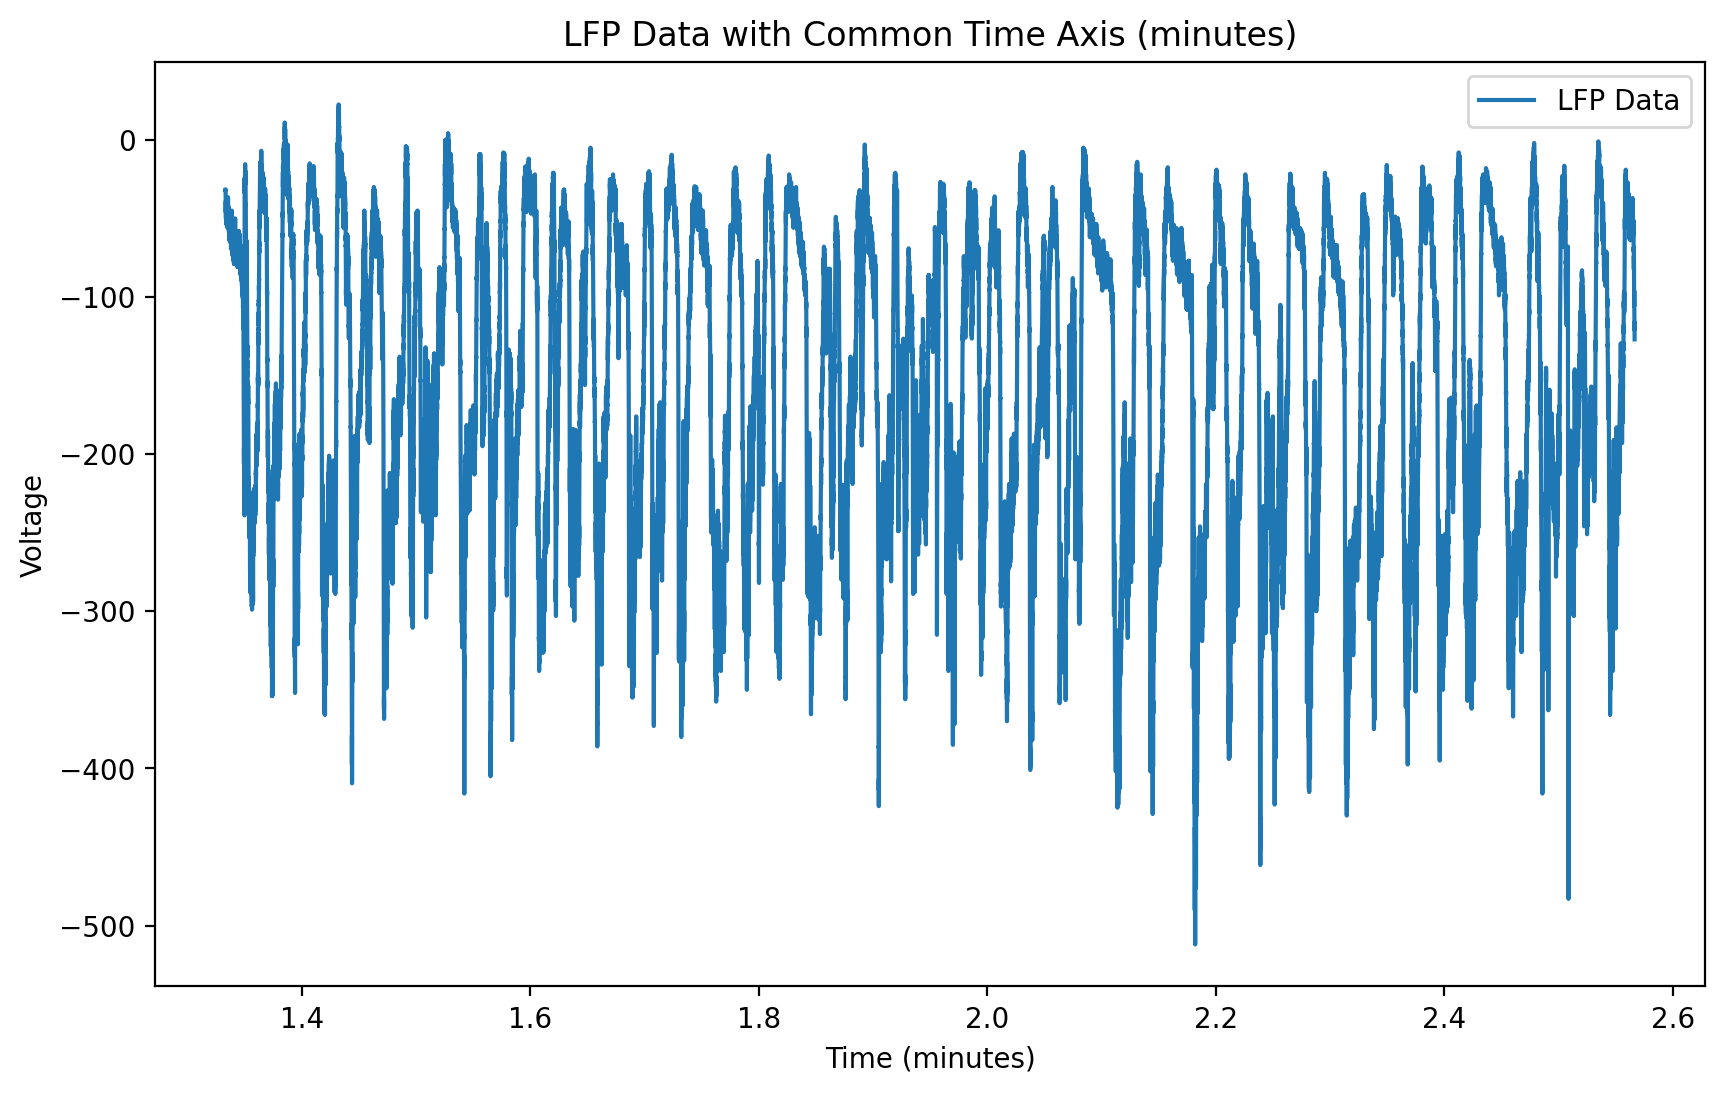

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

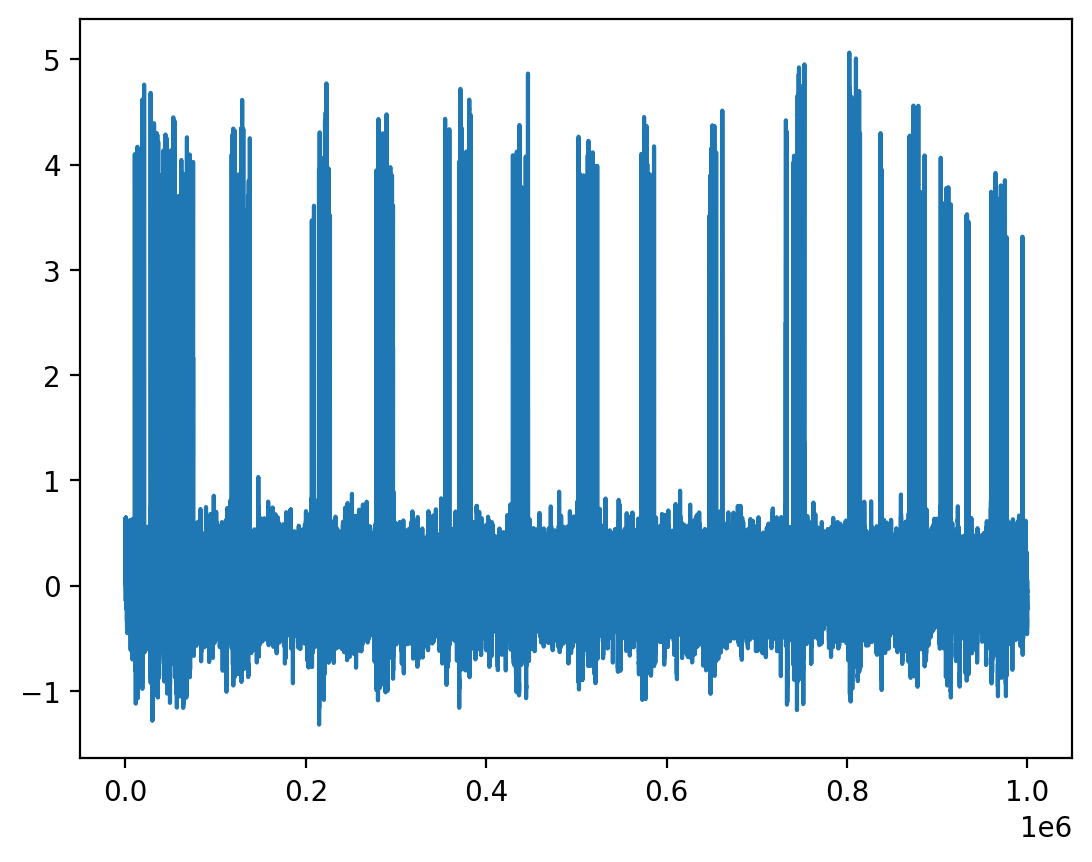

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=2, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1121 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


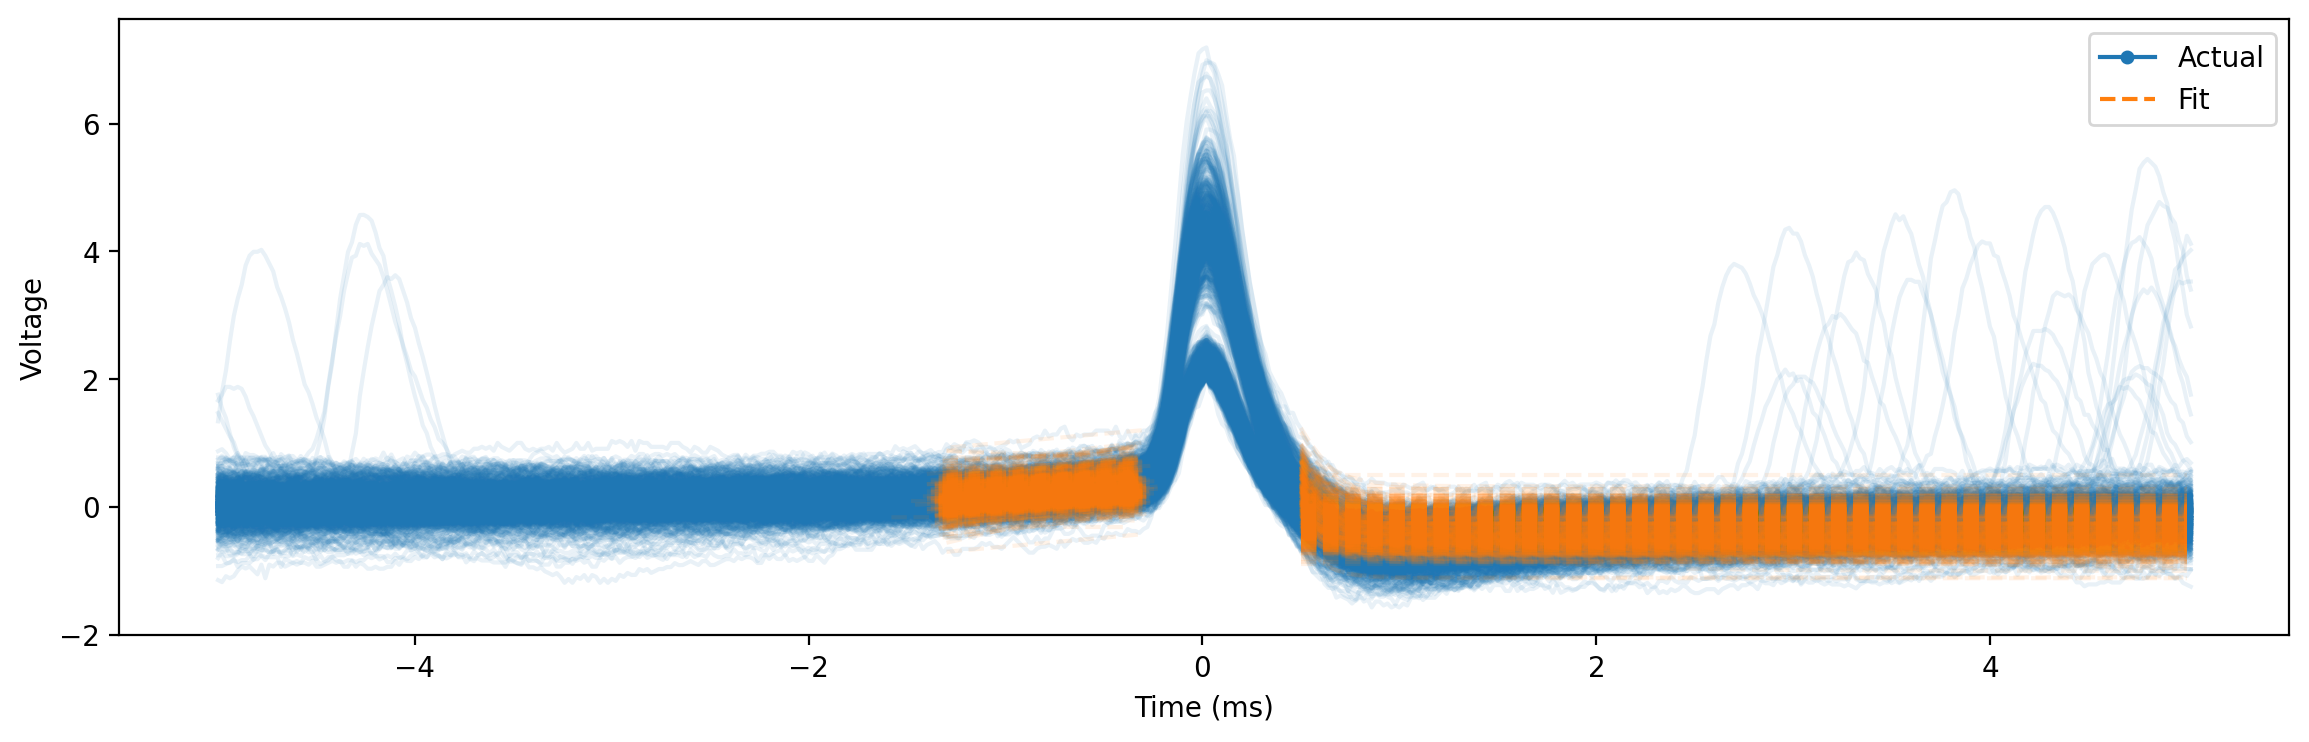

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

(array([106.,  32.,   7.,  31.,  95.,  54.,  24.,  15.,   2.,   1.]),
 array([1.90579096, 2.38152524, 2.85725952, 3.33299381, 3.80872809,
        4.28446237, 4.76019666, 5.23593094, 5.71166522, 6.18739951,
        6.66313379]),
 <BarContainer object of 10 artists>)

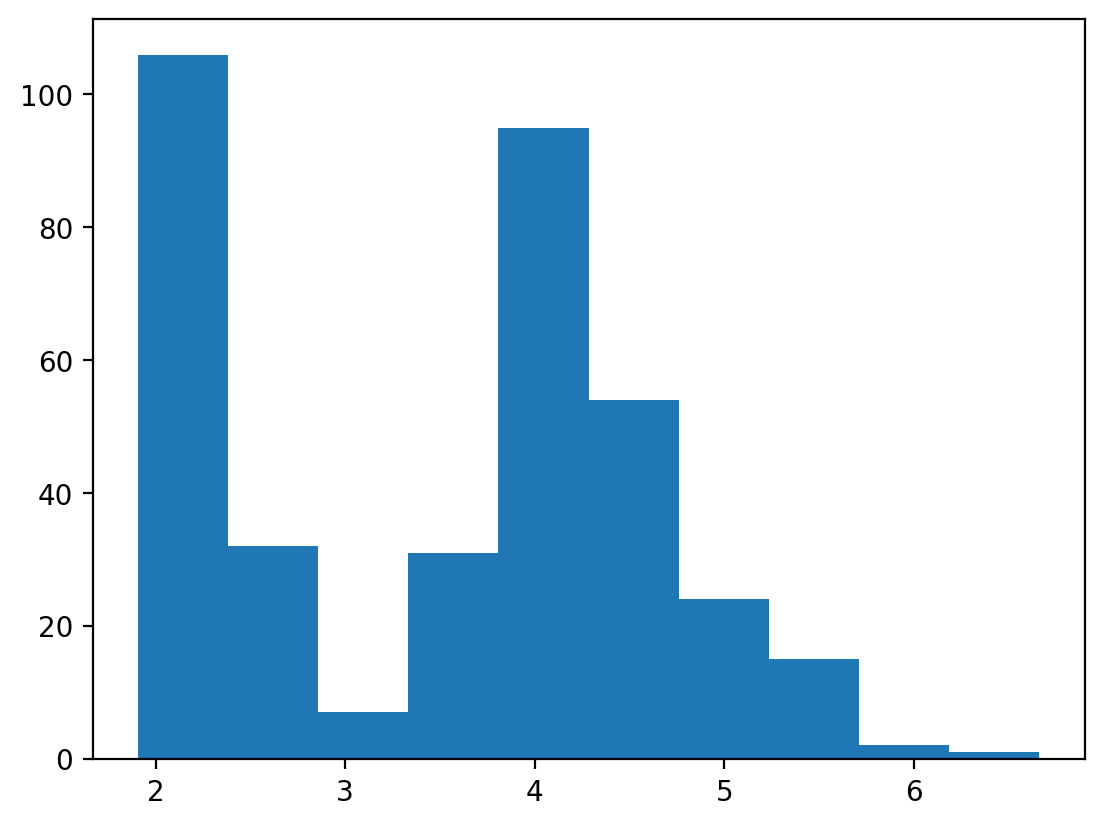

In [13]:
plt.hist(df_features["peak_amp"])

In [14]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
4,0.242062,0.32,0.671918,4.696013,0.36,0.867873,6.667226,-0.435759,2.159420,20729,414.381770,0
6,0.505298,0.32,0.592100,4.072826,0.36,0.685190,4.895196,-0.621922,1.301690,30740,614.506036,1
7,0.133313,0.30,0.759068,4.209874,0.38,0.641494,4.698824,-0.347576,1.400848,31742,634.536454,2
8,0.316290,0.32,0.370061,4.030241,0.38,0.760214,7.286500,-0.316424,1.565168,33001,659.704414,3
12,0.256787,0.32,0.509513,3.777433,0.44,0.640342,3.190649,-0.288256,1.380365,41074,821.087212,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1079,0.362000,0.32,0.196945,2.059886,0.30,0.534854,0.000015,-0.019081,3.085233,9430609,188521.995760,362
1101,0.131459,0.28,0.281537,1.989559,0.32,0.380054,0.000007,-0.198738,3.140212,10730841,214514.201735,363
1102,0.171250,0.34,0.149873,1.951021,0.34,0.335304,0.000005,-0.043210,2.505918,10799927,215895.261070,364
1107,0.195389,0.36,0.305823,2.016039,0.32,0.442808,0.000002,0.019728,3.294849,11007785,220050.433339,365


### Get spike times


In [15]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster spike groups 

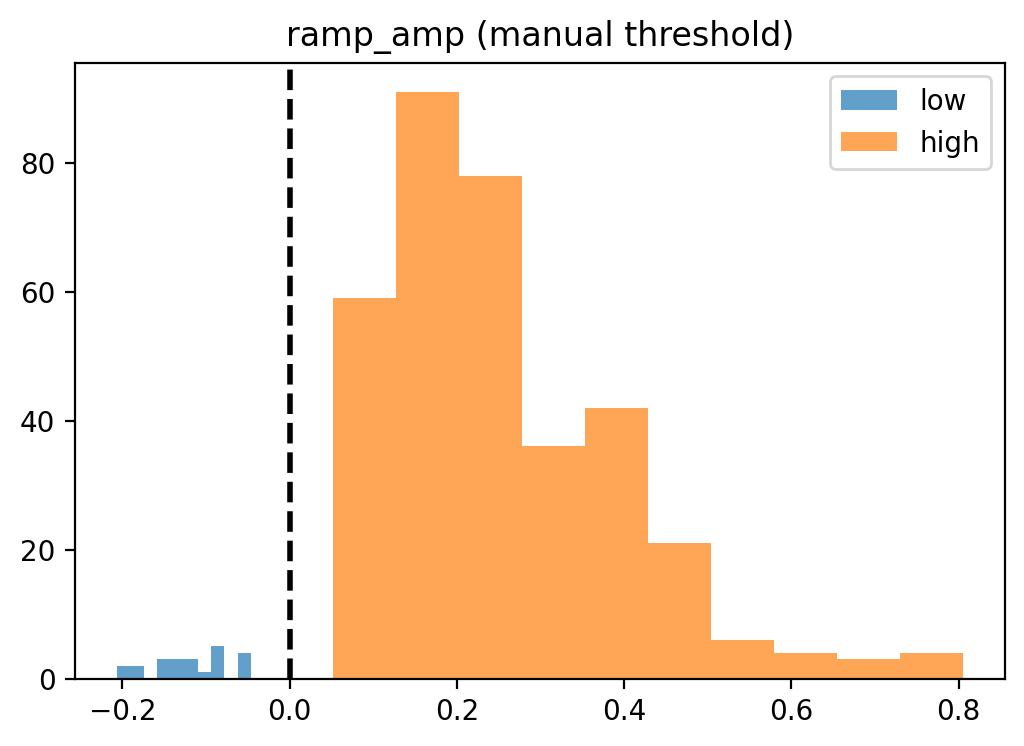

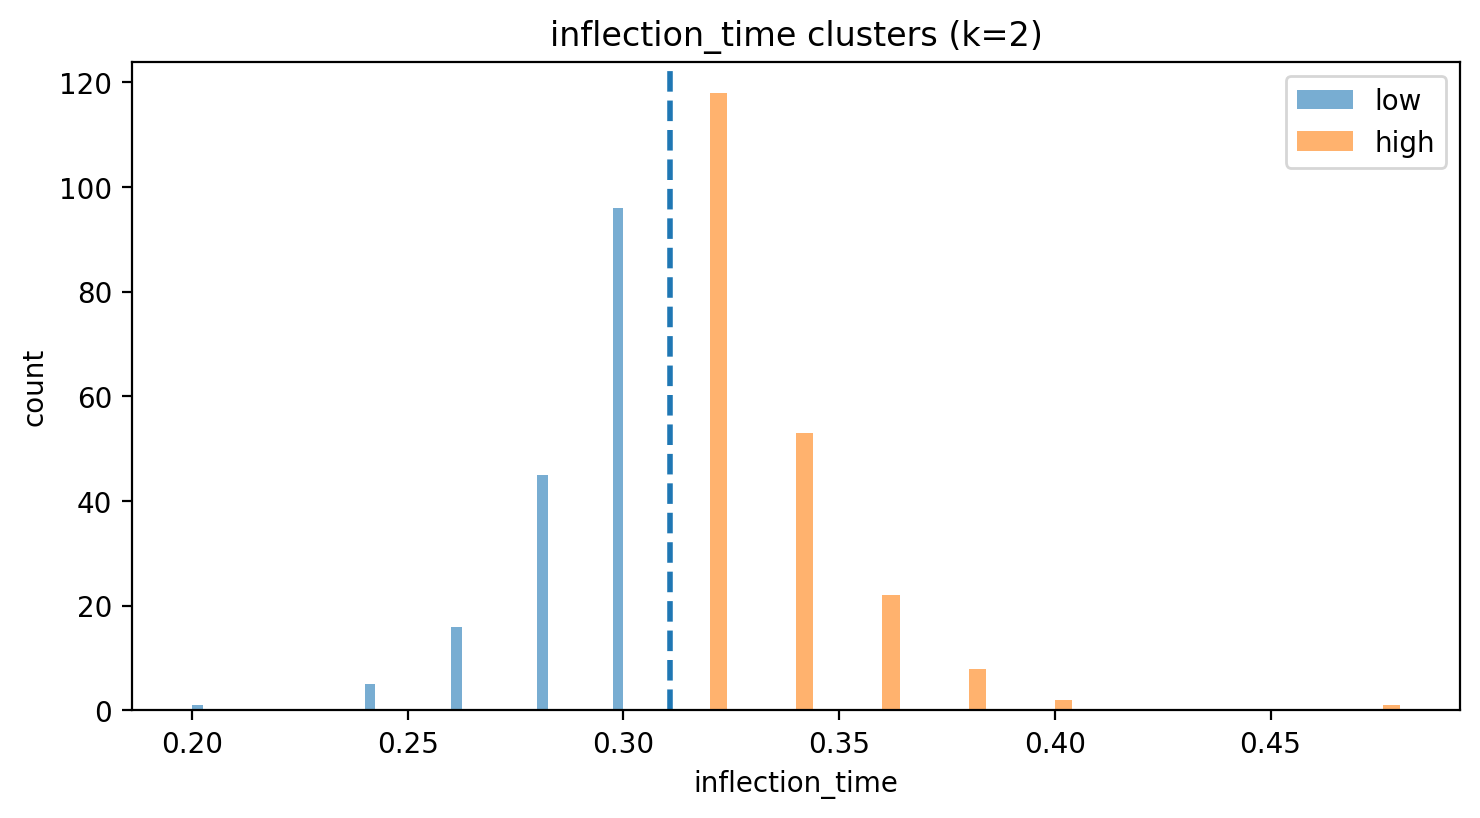

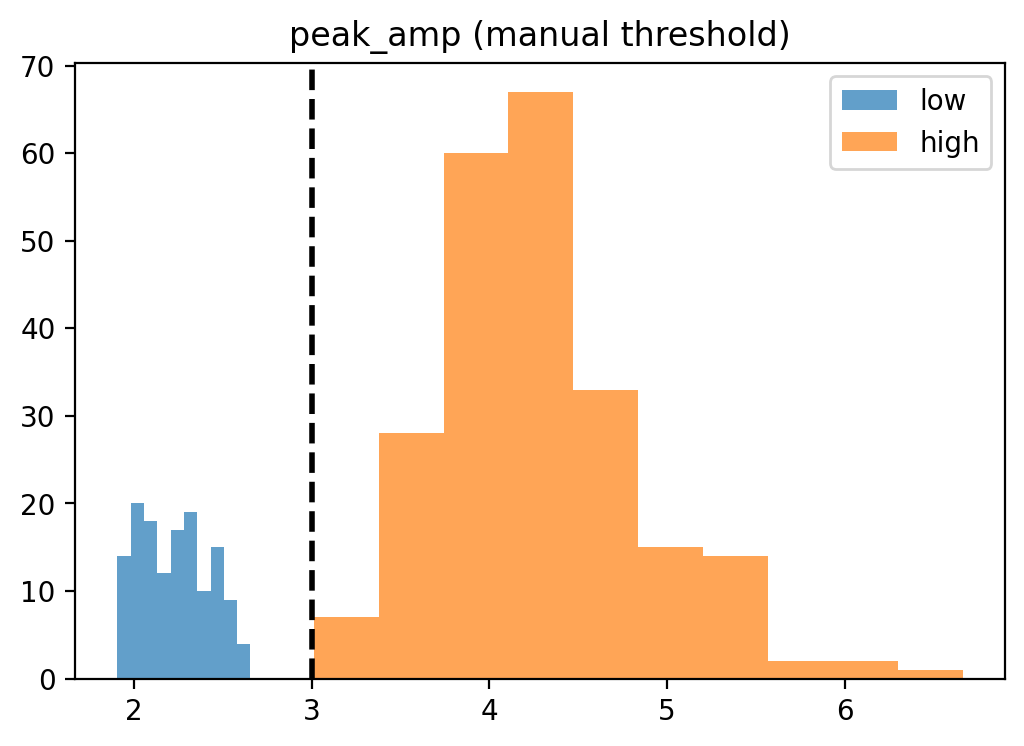

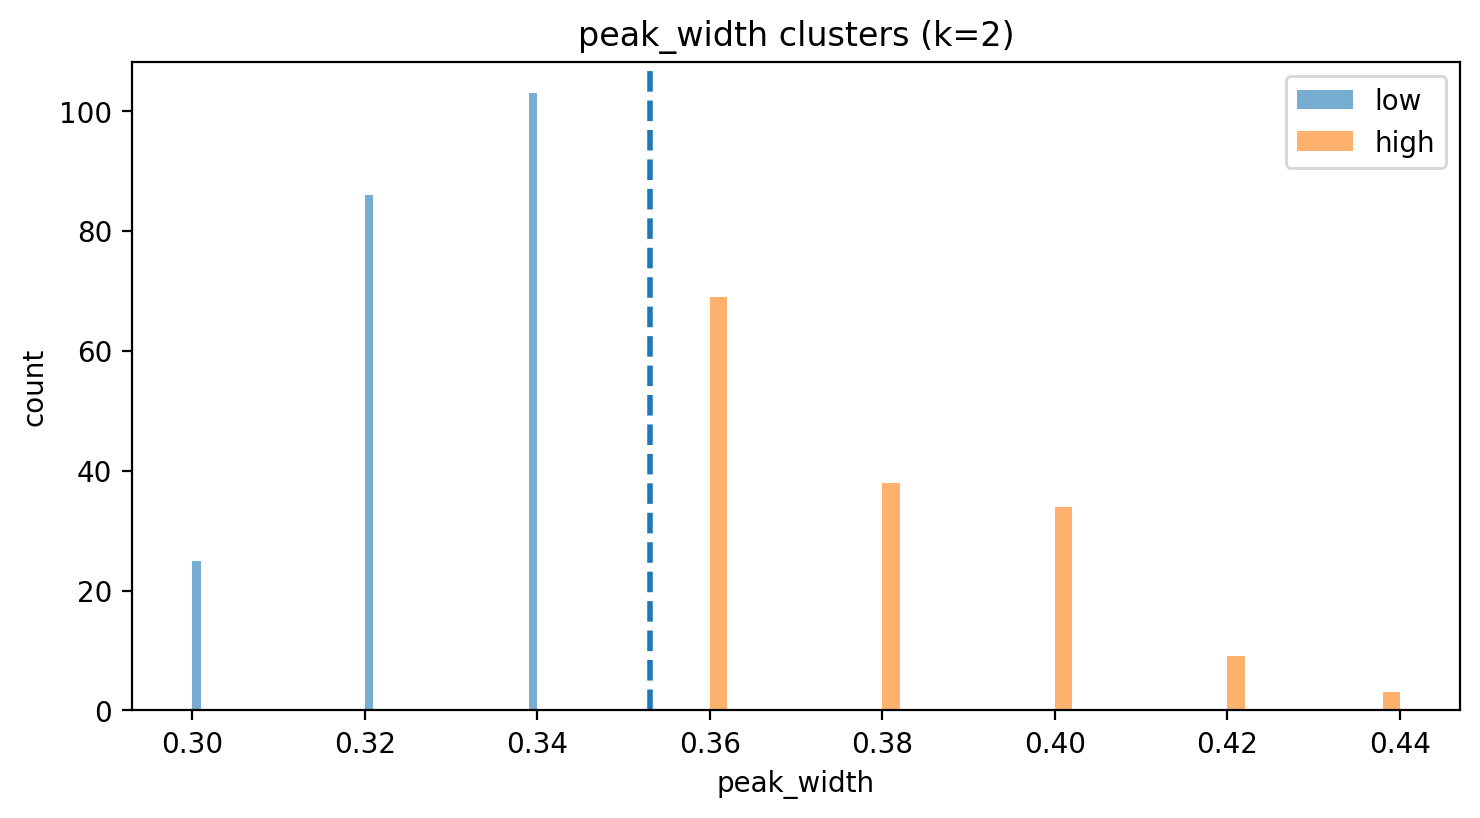

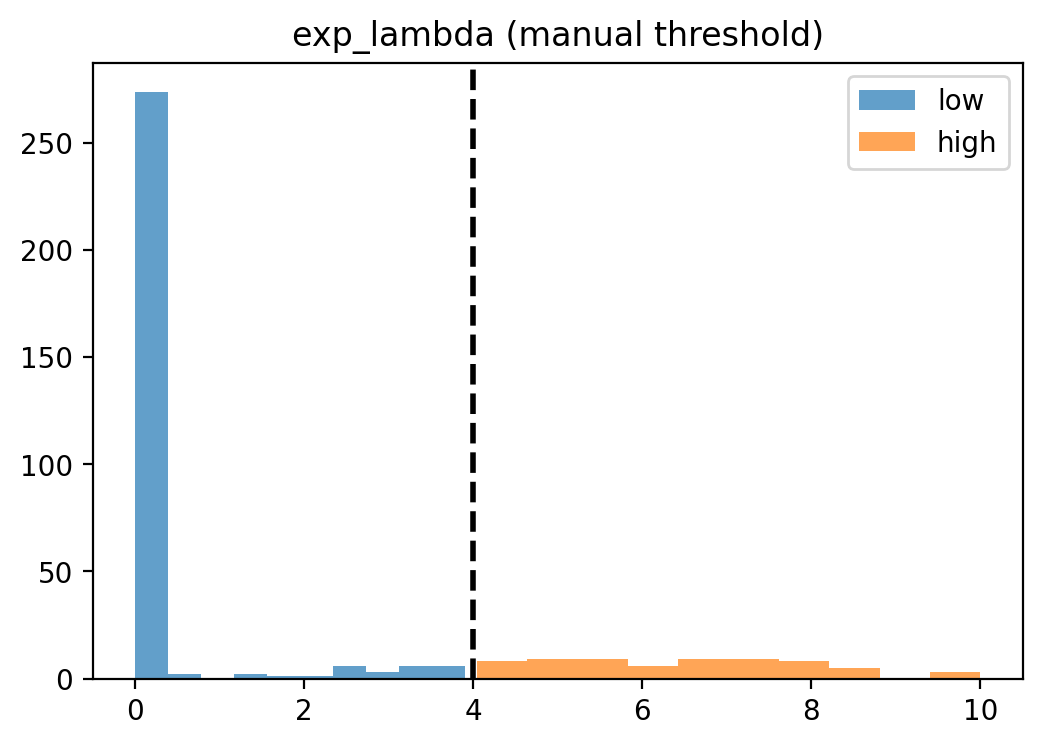

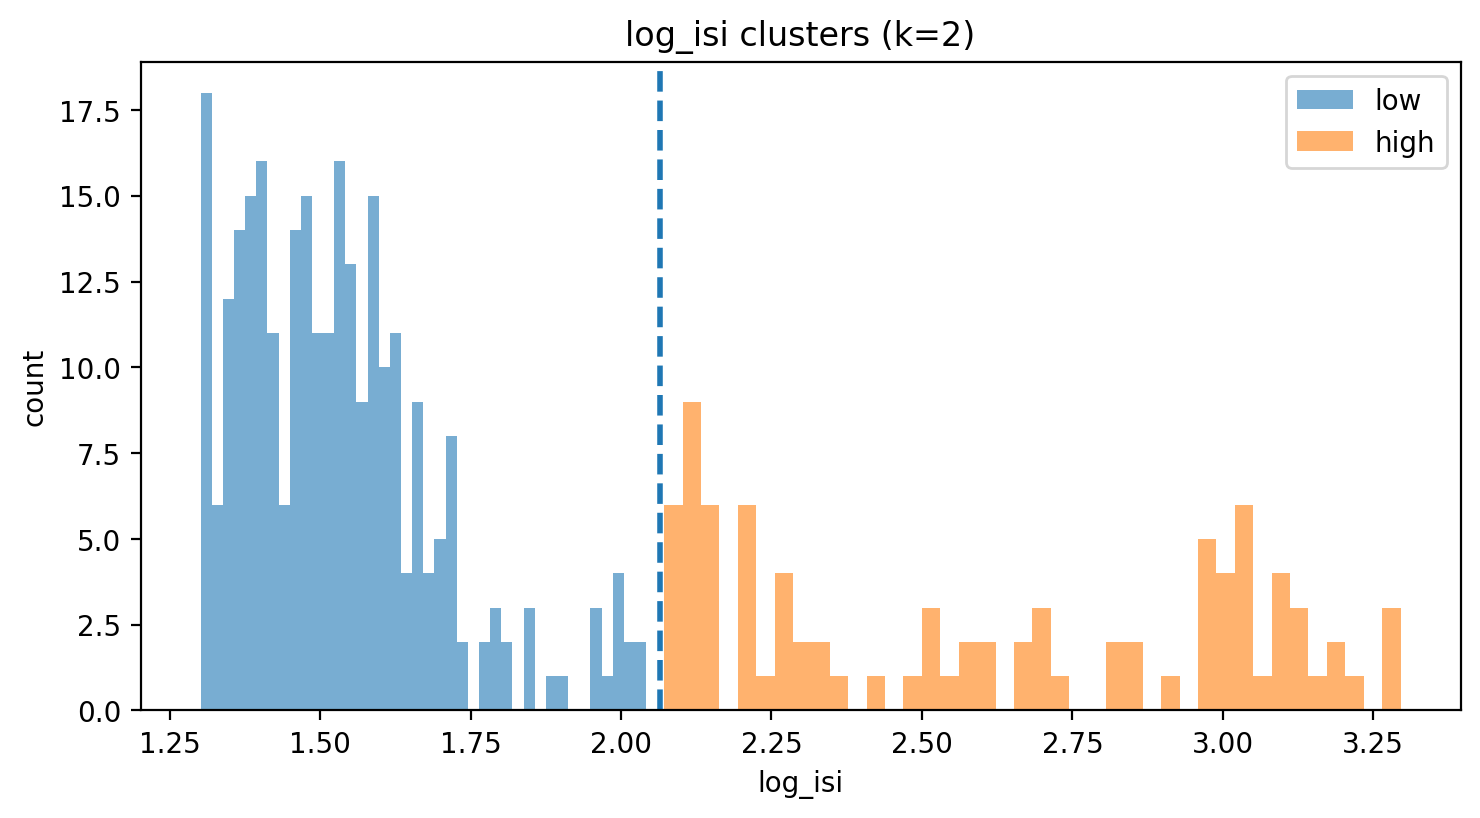

In [16]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=2,
    suffix="_cluster",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={
        'ramp_amp': 0, 'exp_lambda':4, 'peak_amp':3
    }
)







In [17]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,inflection_time_cluster,peak_amp_cluster,peak_width_cluster,exp_lambda_cluster,log_isi_cluster
4,0.242062,0.32,0.671918,4.696013,0.36,0.867873,6.667226,-0.435759,2.159420,20729,414.381770,0,high,high,high,high,high,high
6,0.505298,0.32,0.592100,4.072826,0.36,0.685190,4.895196,-0.621922,1.301690,30740,614.506036,1,high,high,high,high,high,low
7,0.133313,0.30,0.759068,4.209874,0.38,0.641494,4.698824,-0.347576,1.400848,31742,634.536454,2,high,low,high,high,high,low
8,0.316290,0.32,0.370061,4.030241,0.38,0.760214,7.286500,-0.316424,1.565168,33001,659.704414,3,high,high,high,high,high,low
12,0.256787,0.32,0.509513,3.777433,0.44,0.640342,3.190649,-0.288256,1.380365,41074,821.087212,4,high,high,high,high,low,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1079,0.362000,0.32,0.196945,2.059886,0.30,0.534854,0.000015,-0.019081,3.085233,9430609,188521.995760,362,high,high,low,low,low,high
1101,0.131459,0.28,0.281537,1.989559,0.32,0.380054,0.000007,-0.198738,3.140212,10730841,214514.201735,363,high,low,low,low,low,high
1102,0.171250,0.34,0.149873,1.951021,0.34,0.335304,0.000005,-0.043210,2.505918,10799927,215895.261070,364,high,high,low,low,low,high
1107,0.195389,0.36,0.305823,2.016039,0.32,0.442808,0.000002,0.019728,3.294849,11007785,220050.433339,365,high,high,low,low,low,high


### CLUSTER REPORTS


===== CLUSTER REPORT: ramp_amp_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


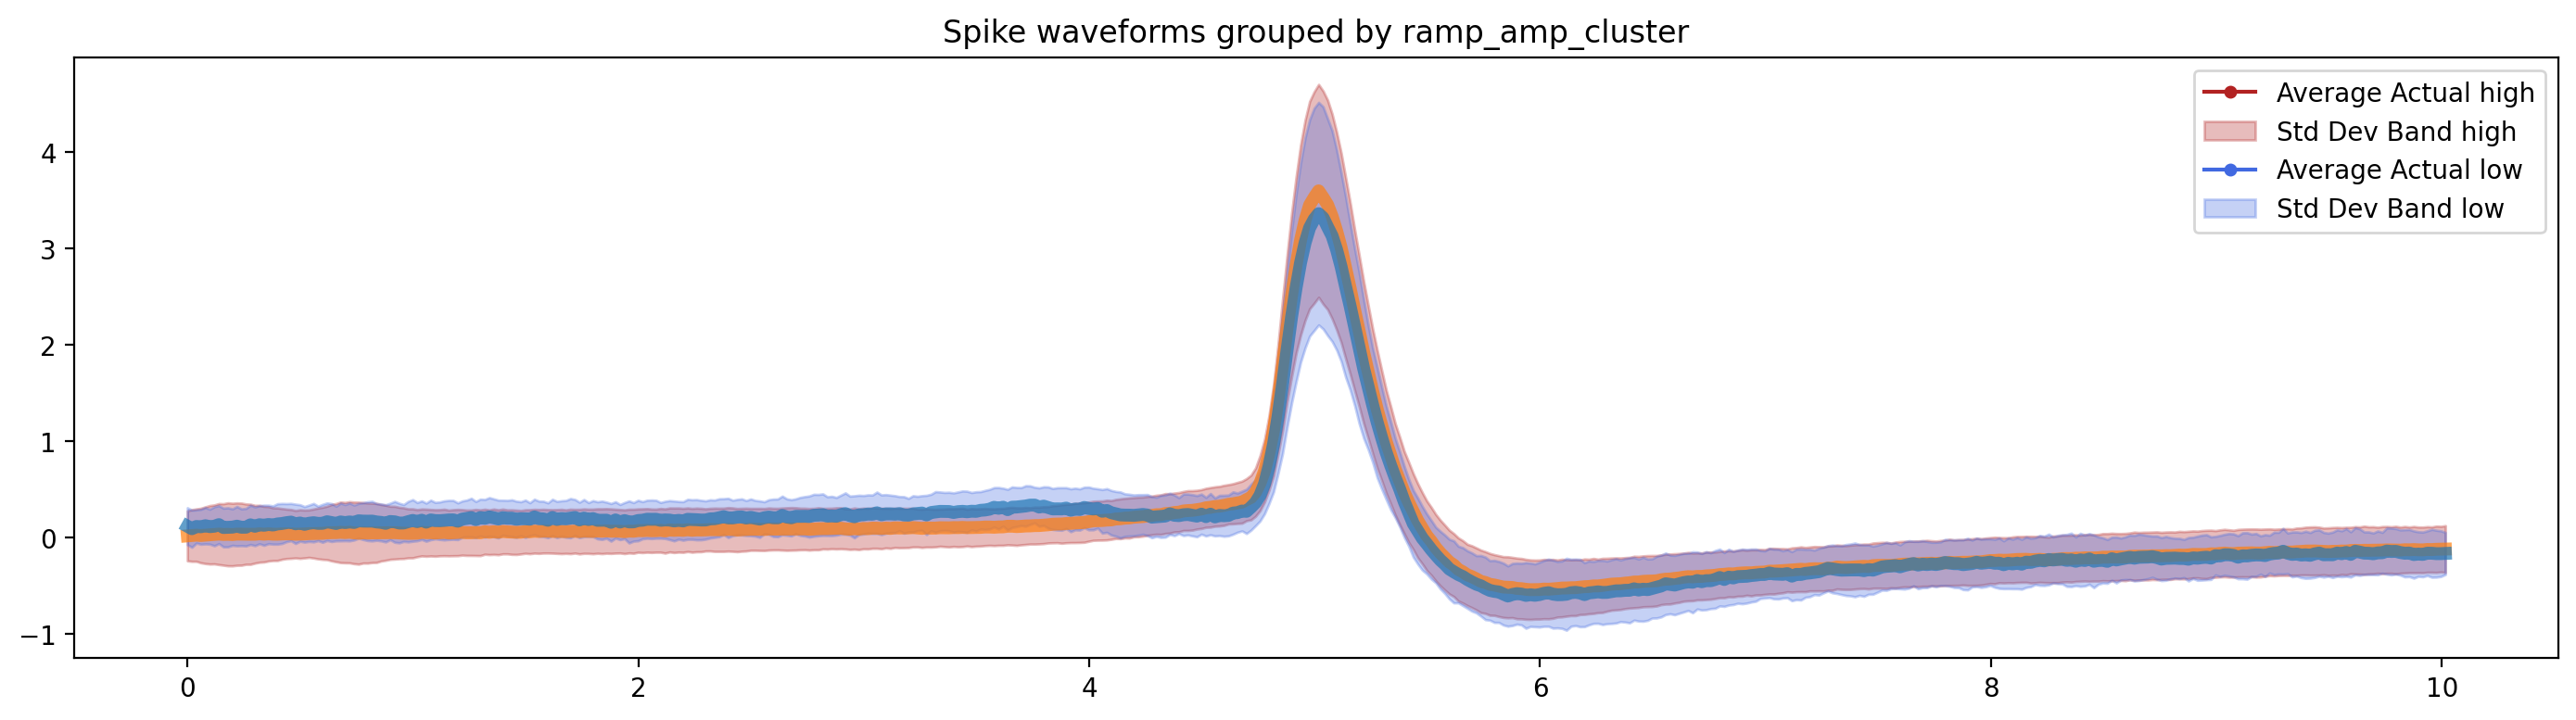

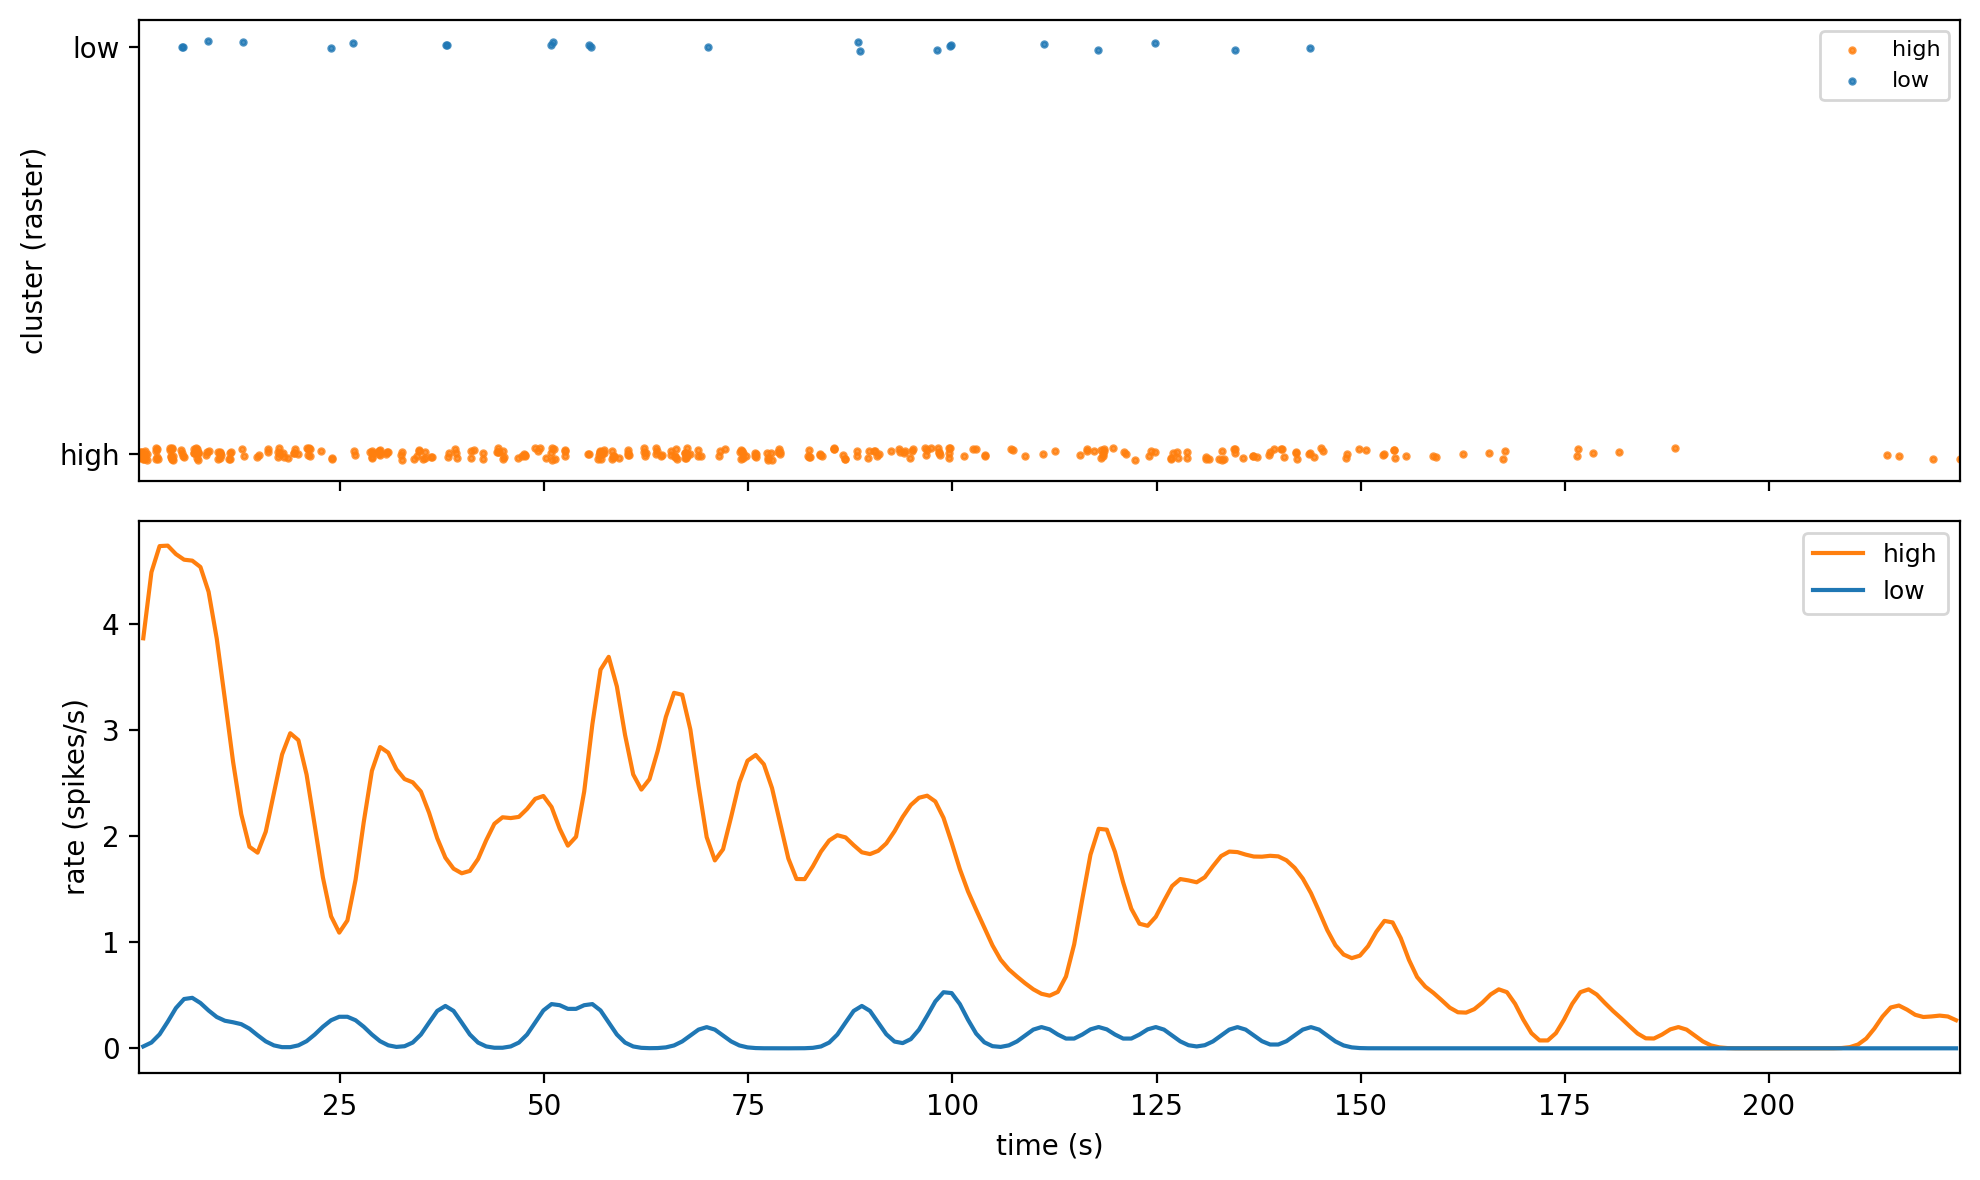

→ Computing cluster transition matrix


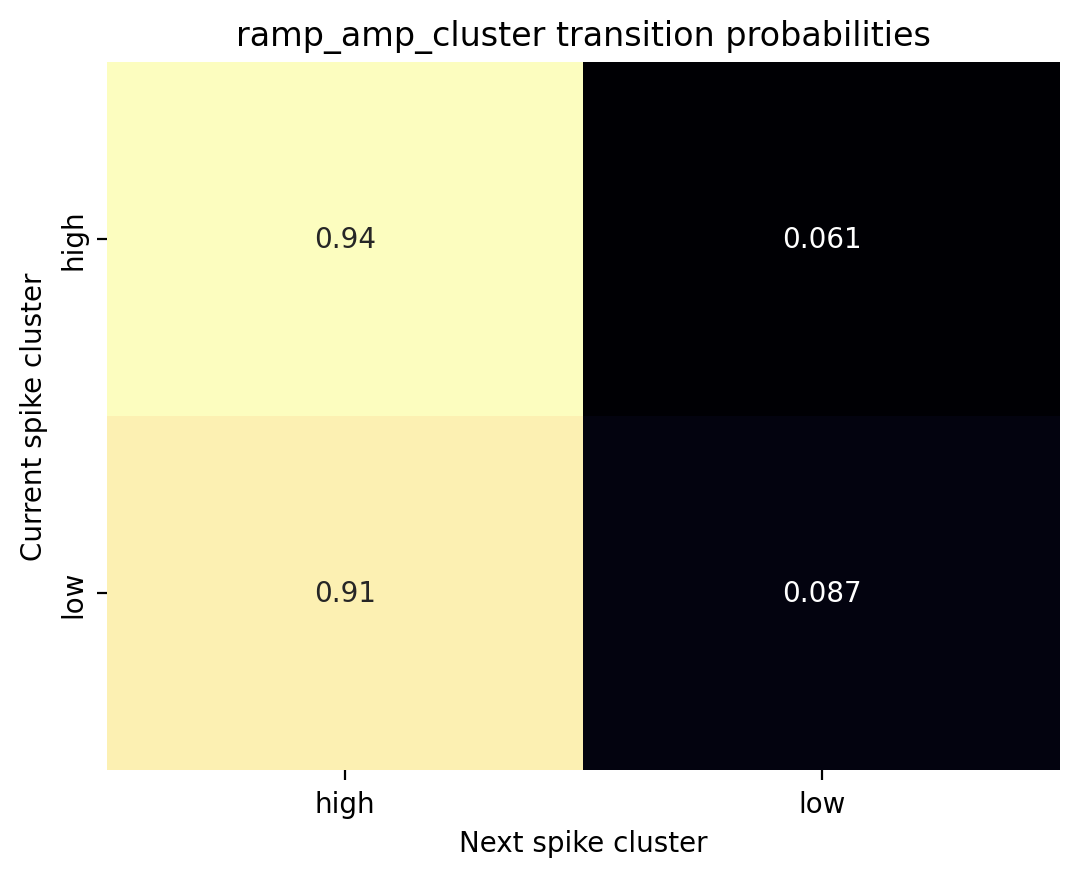

===== DONE =====


===== CLUSTER REPORT: inflection_time_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


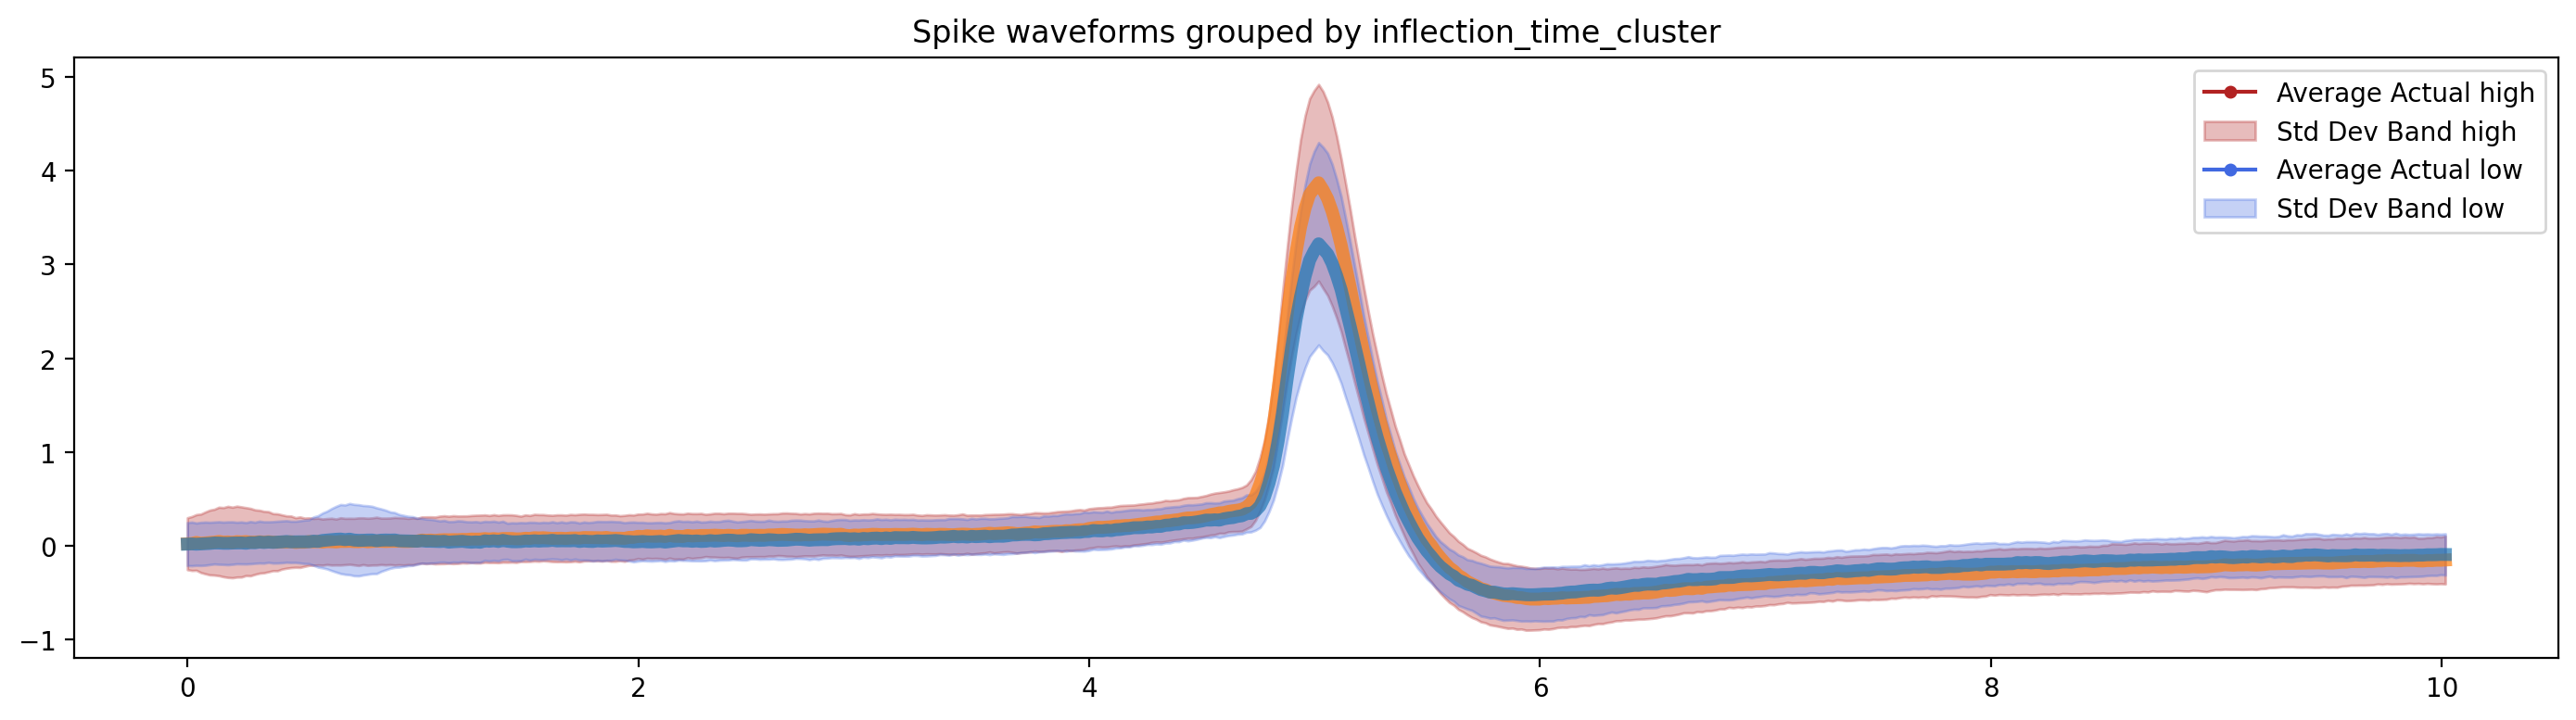

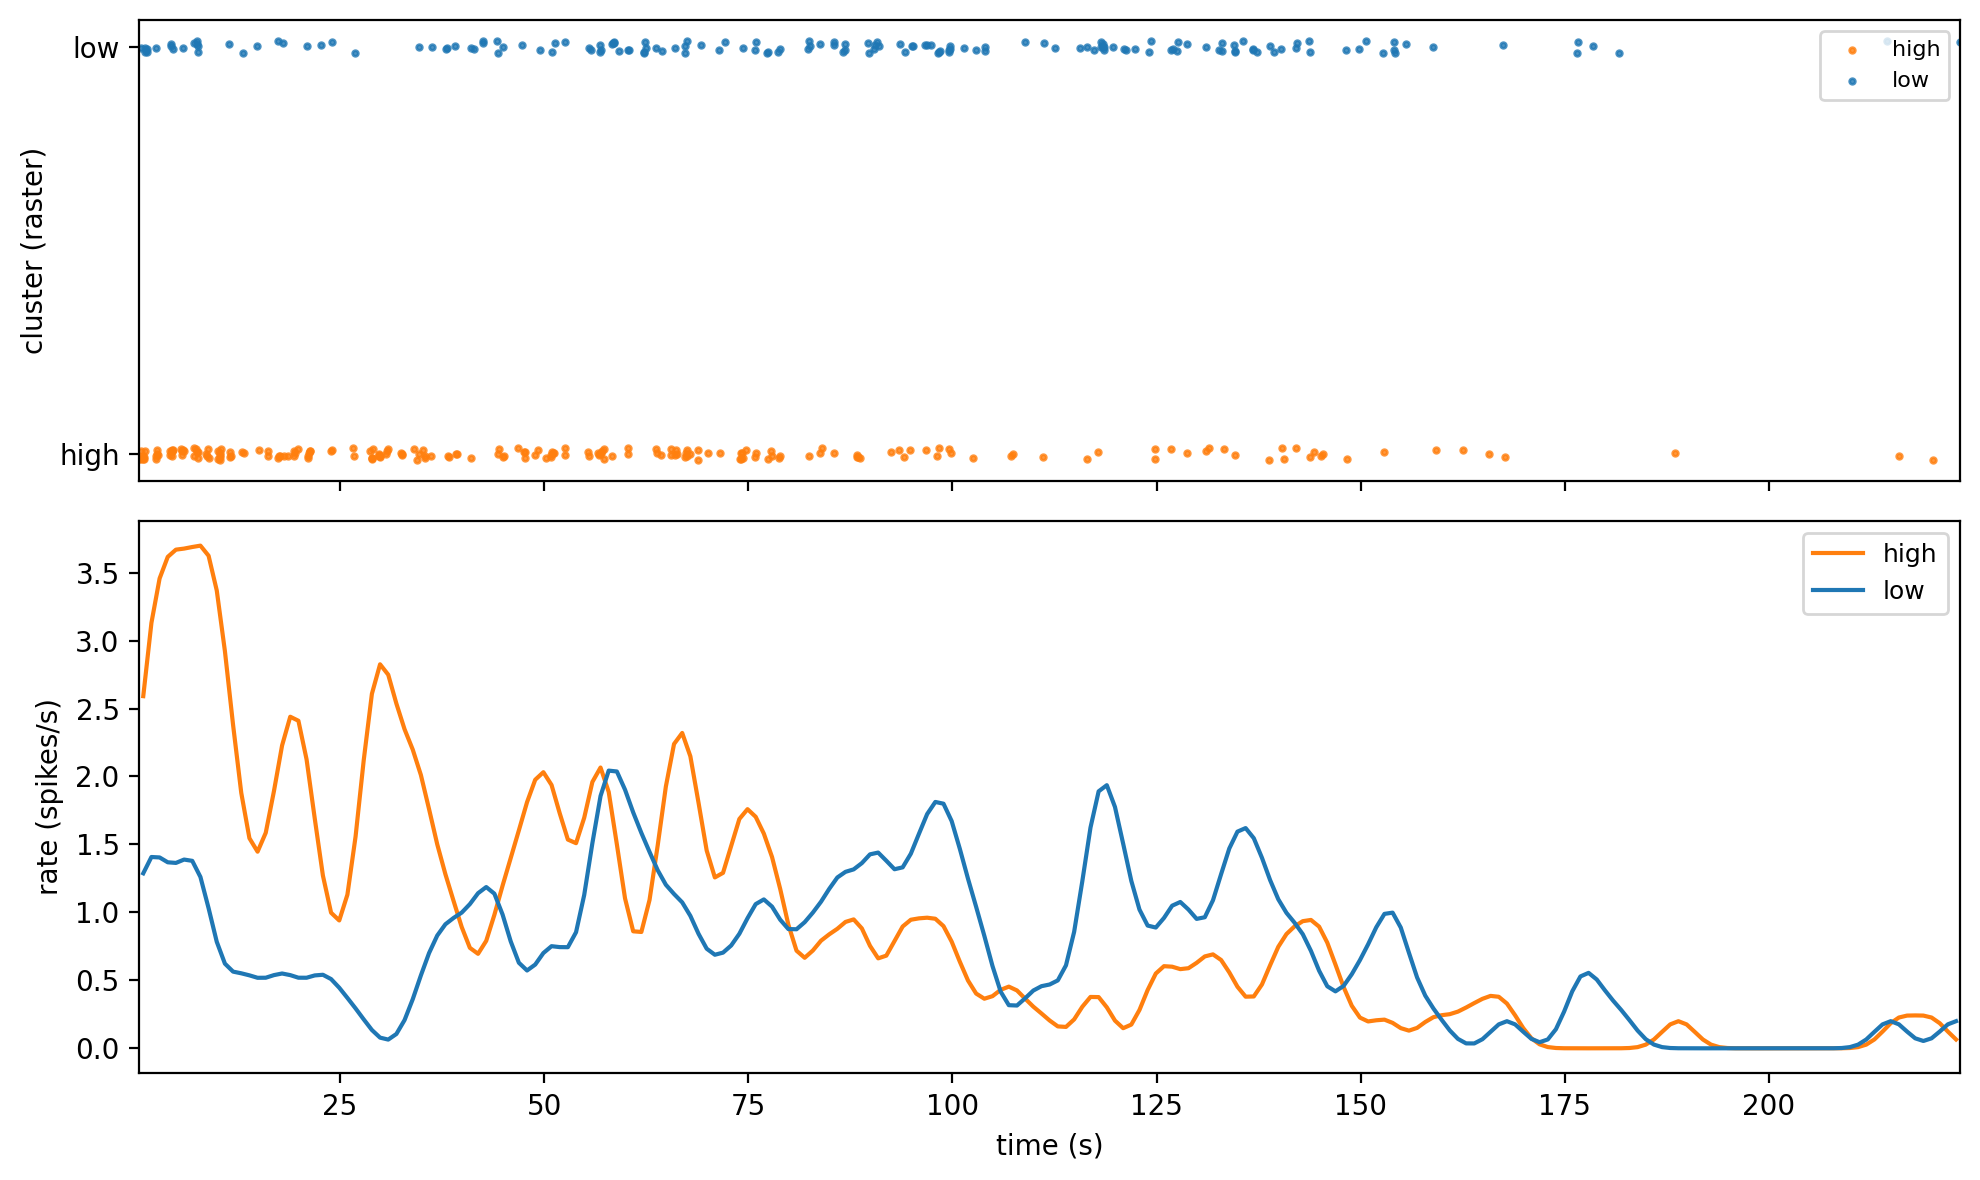

→ Computing cluster transition matrix


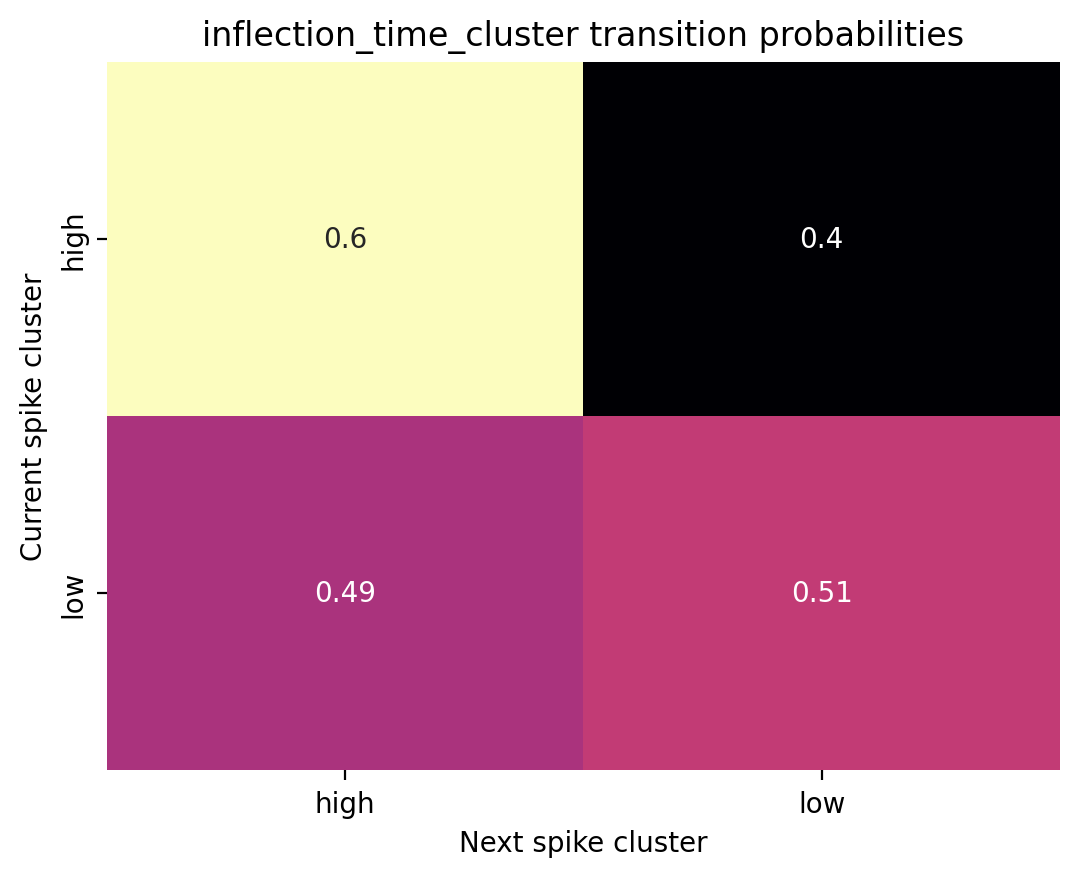

===== DONE =====


===== CLUSTER REPORT: peak_amp_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


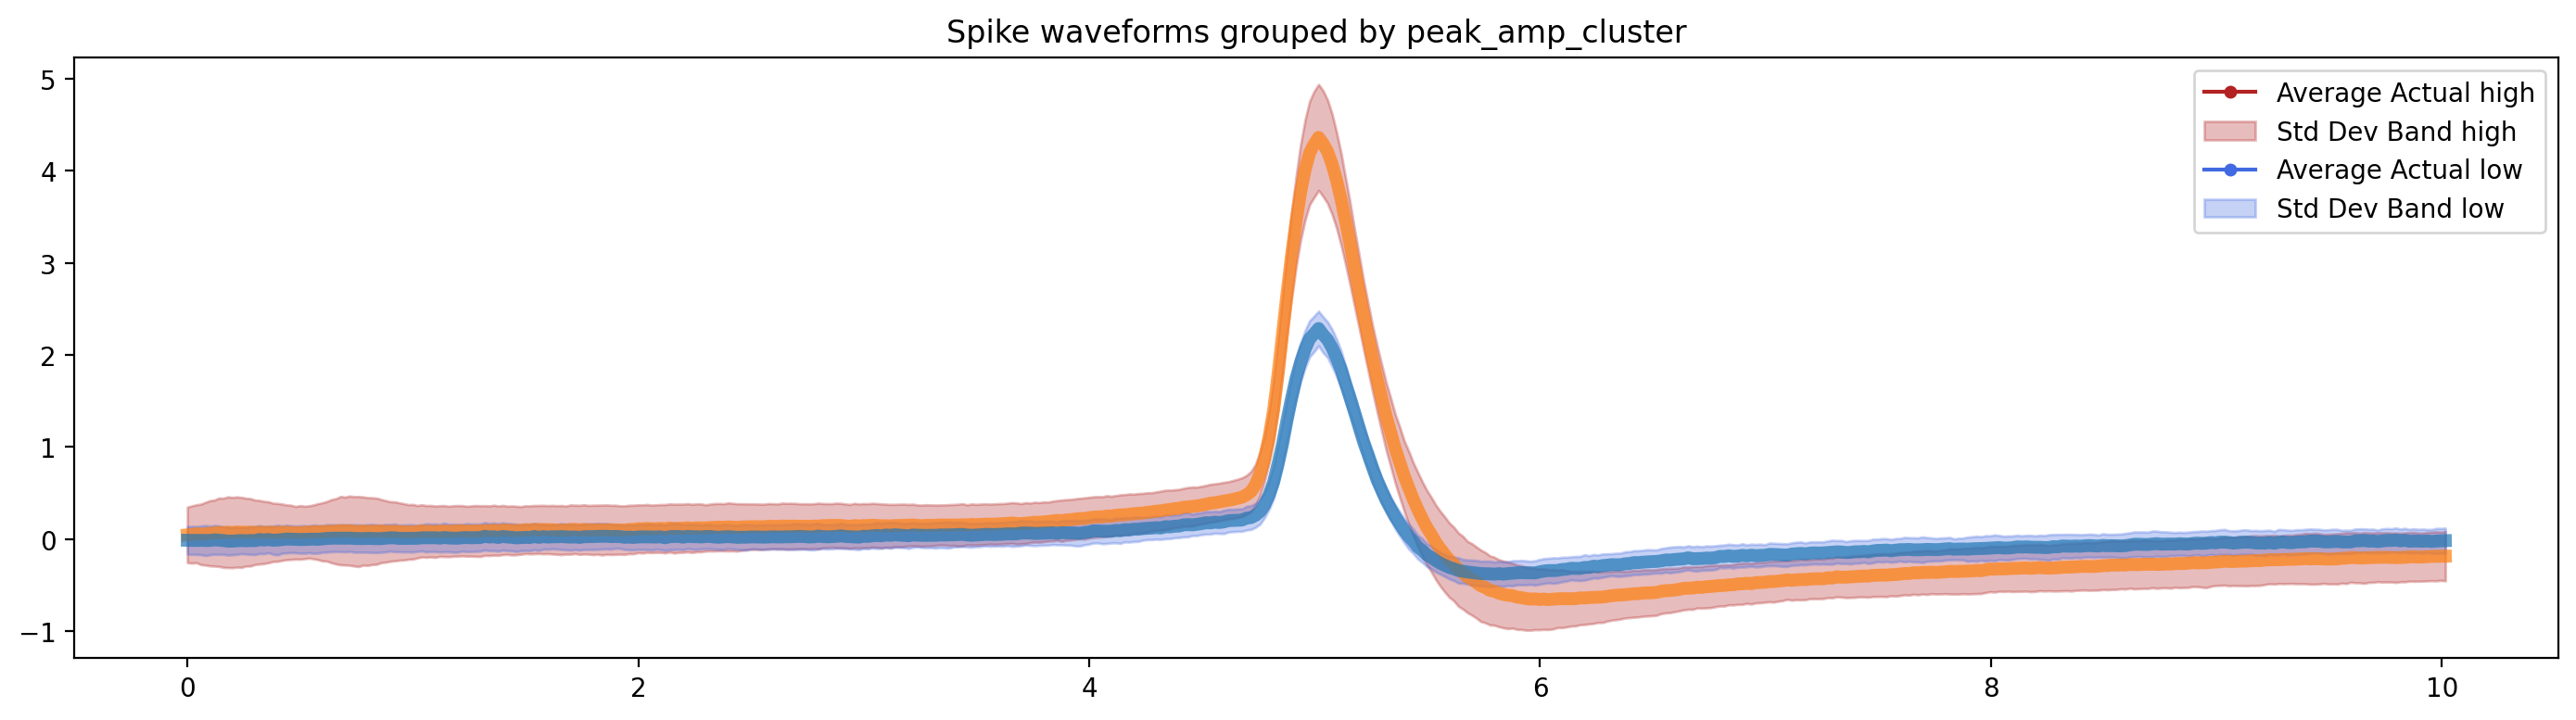

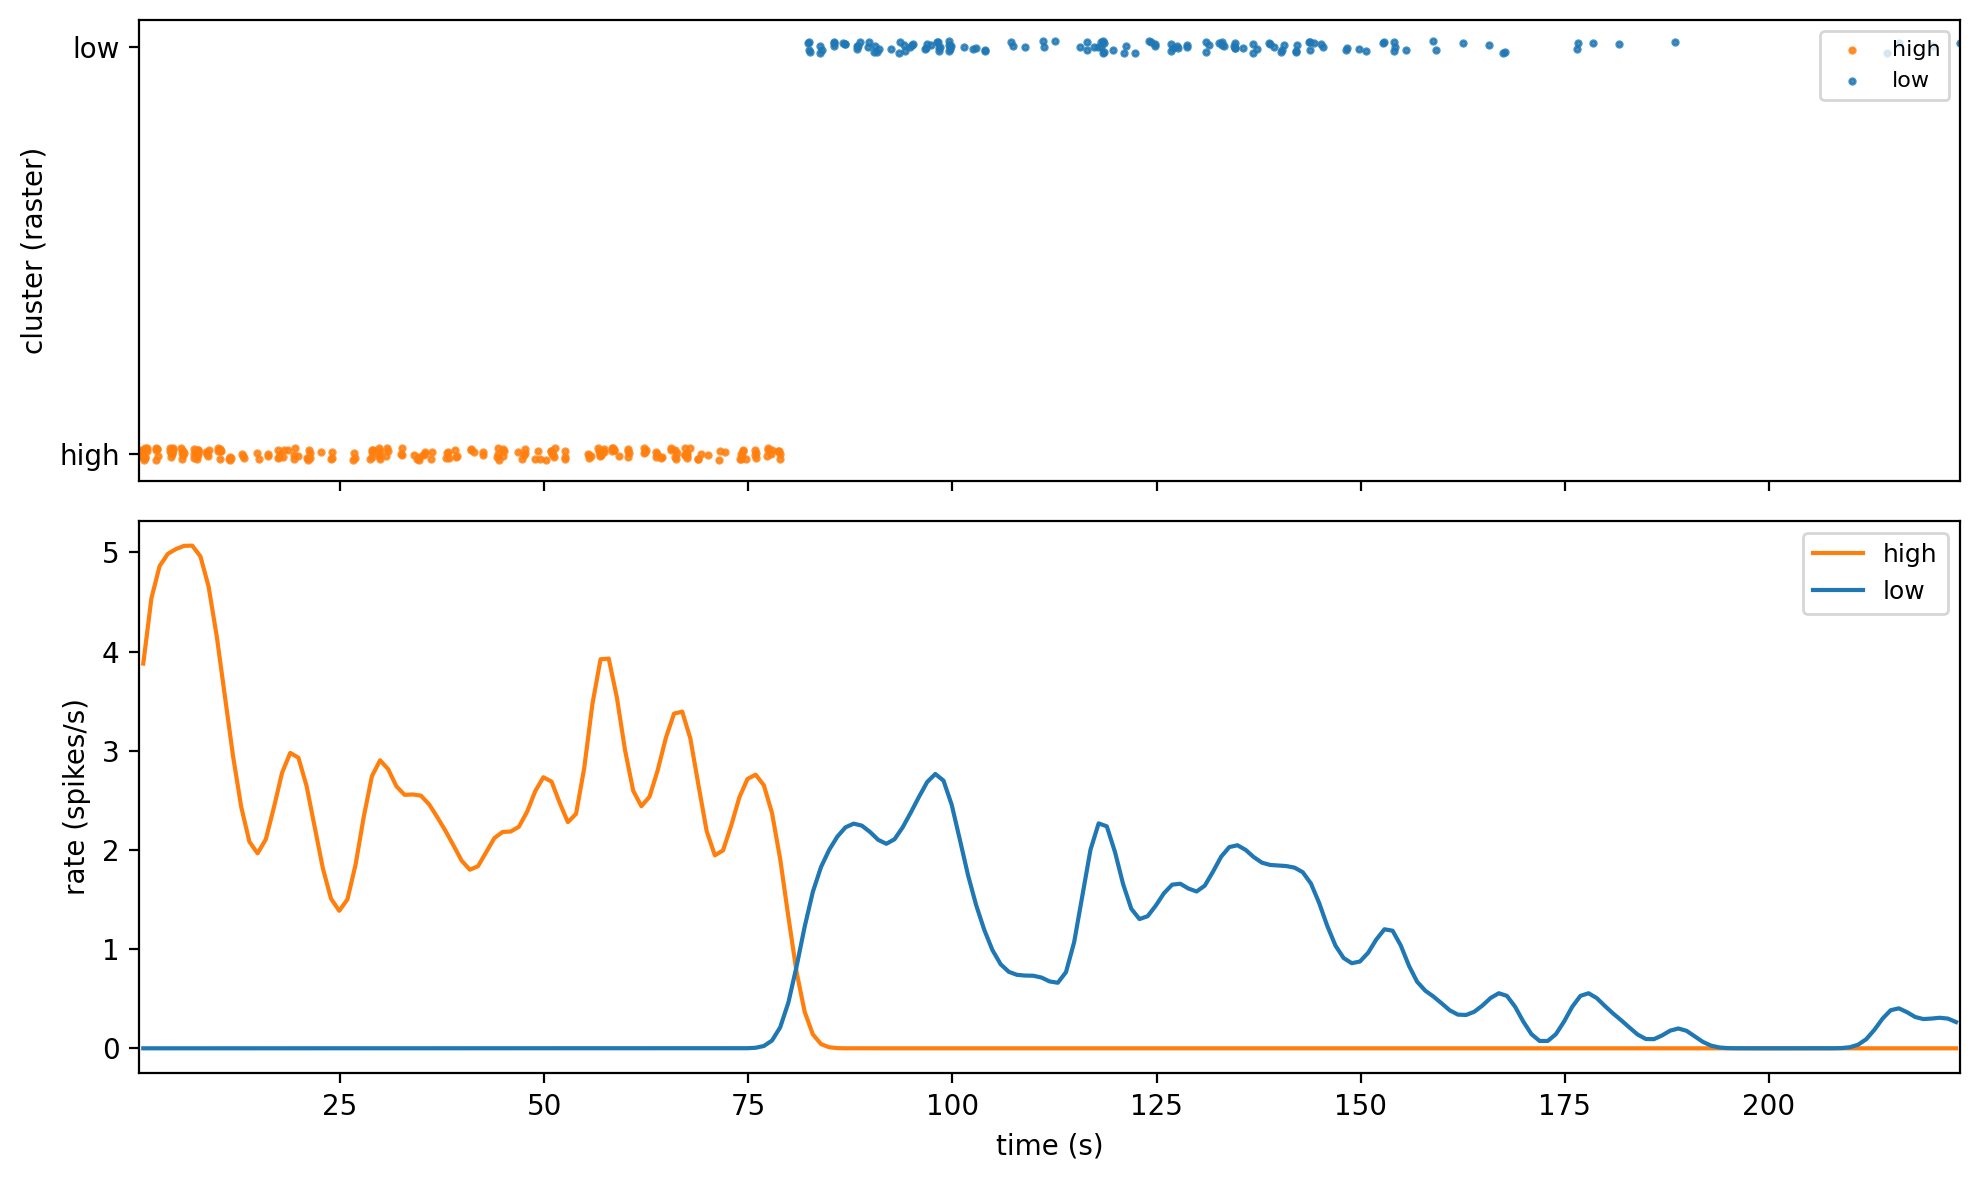

→ Computing cluster transition matrix


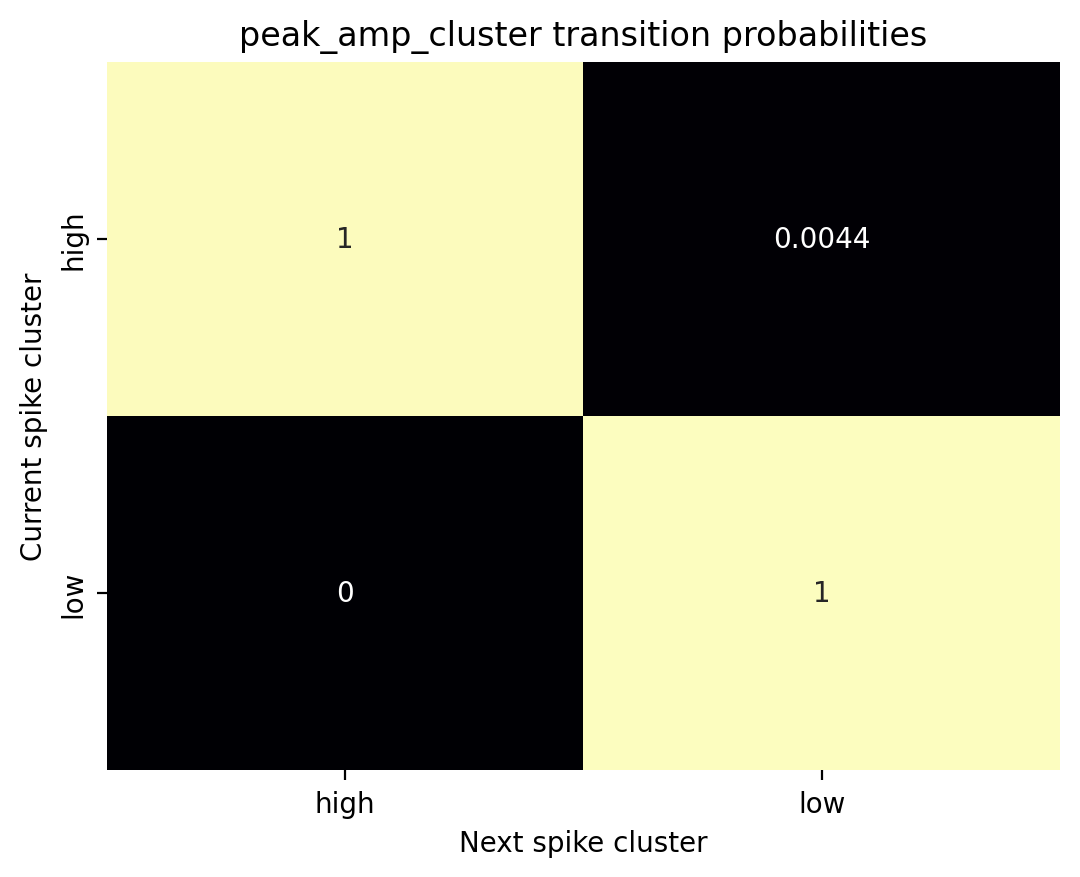

===== DONE =====


===== CLUSTER REPORT: peak_width_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


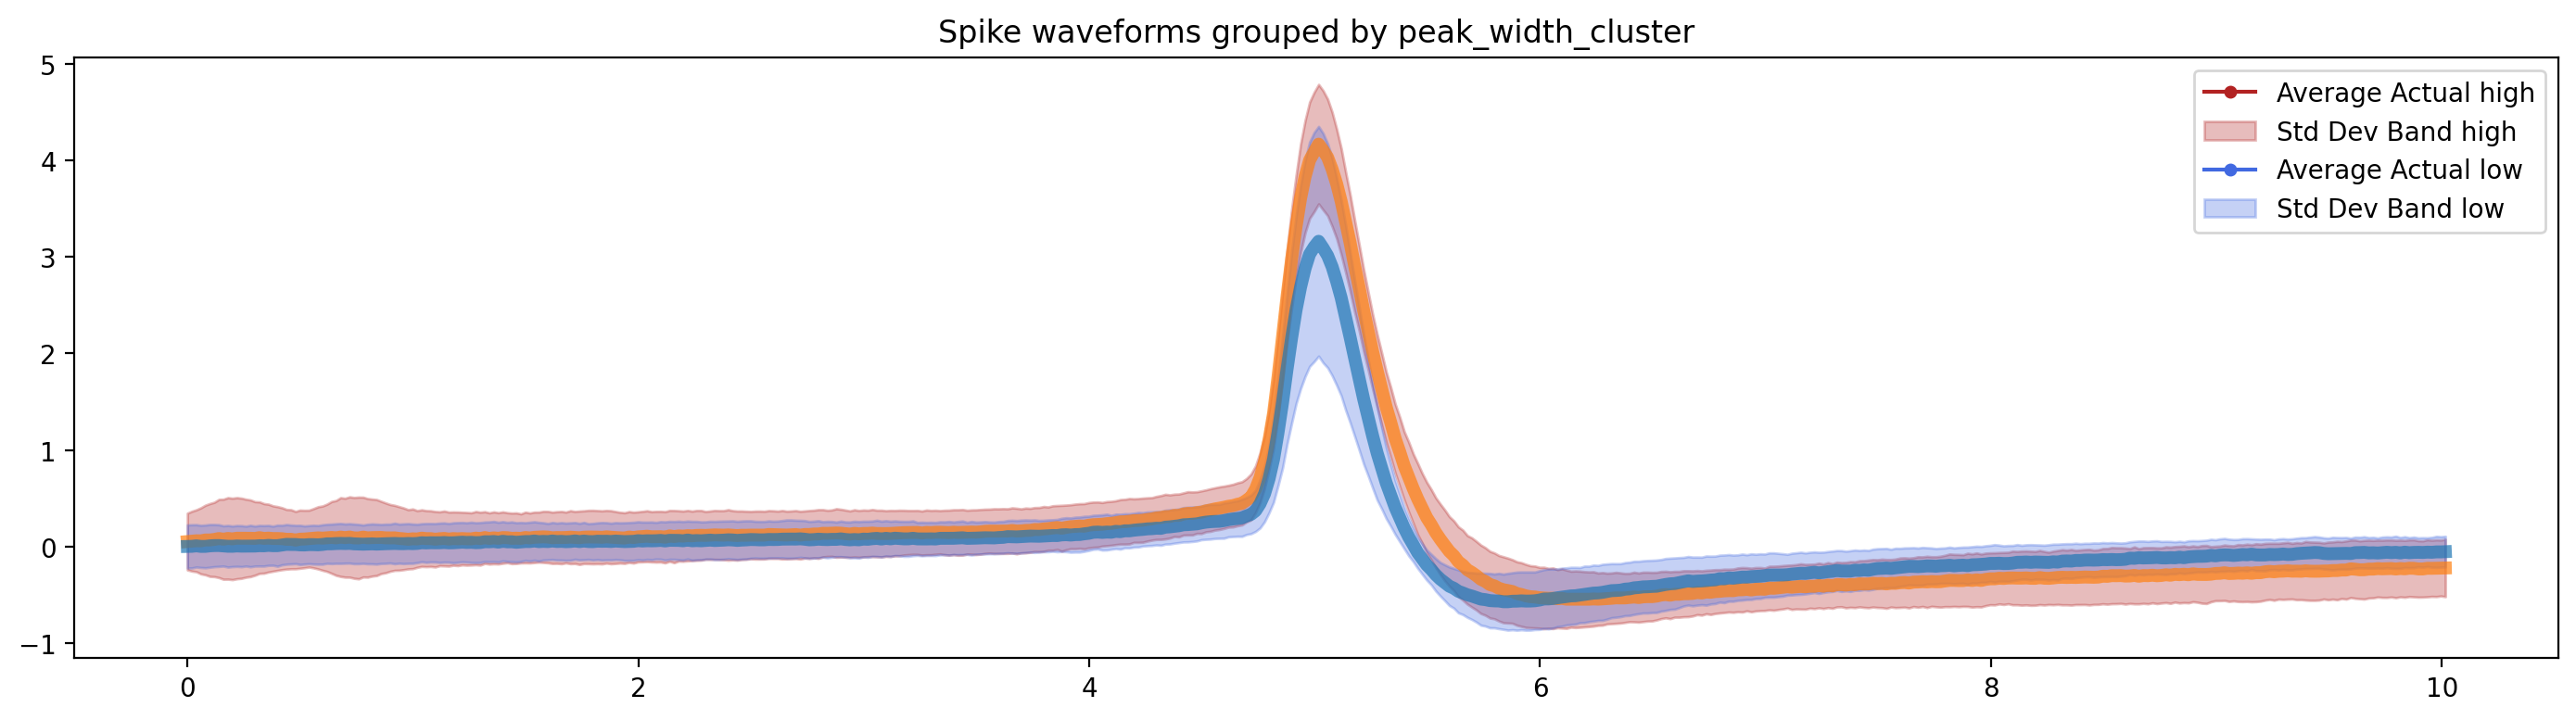

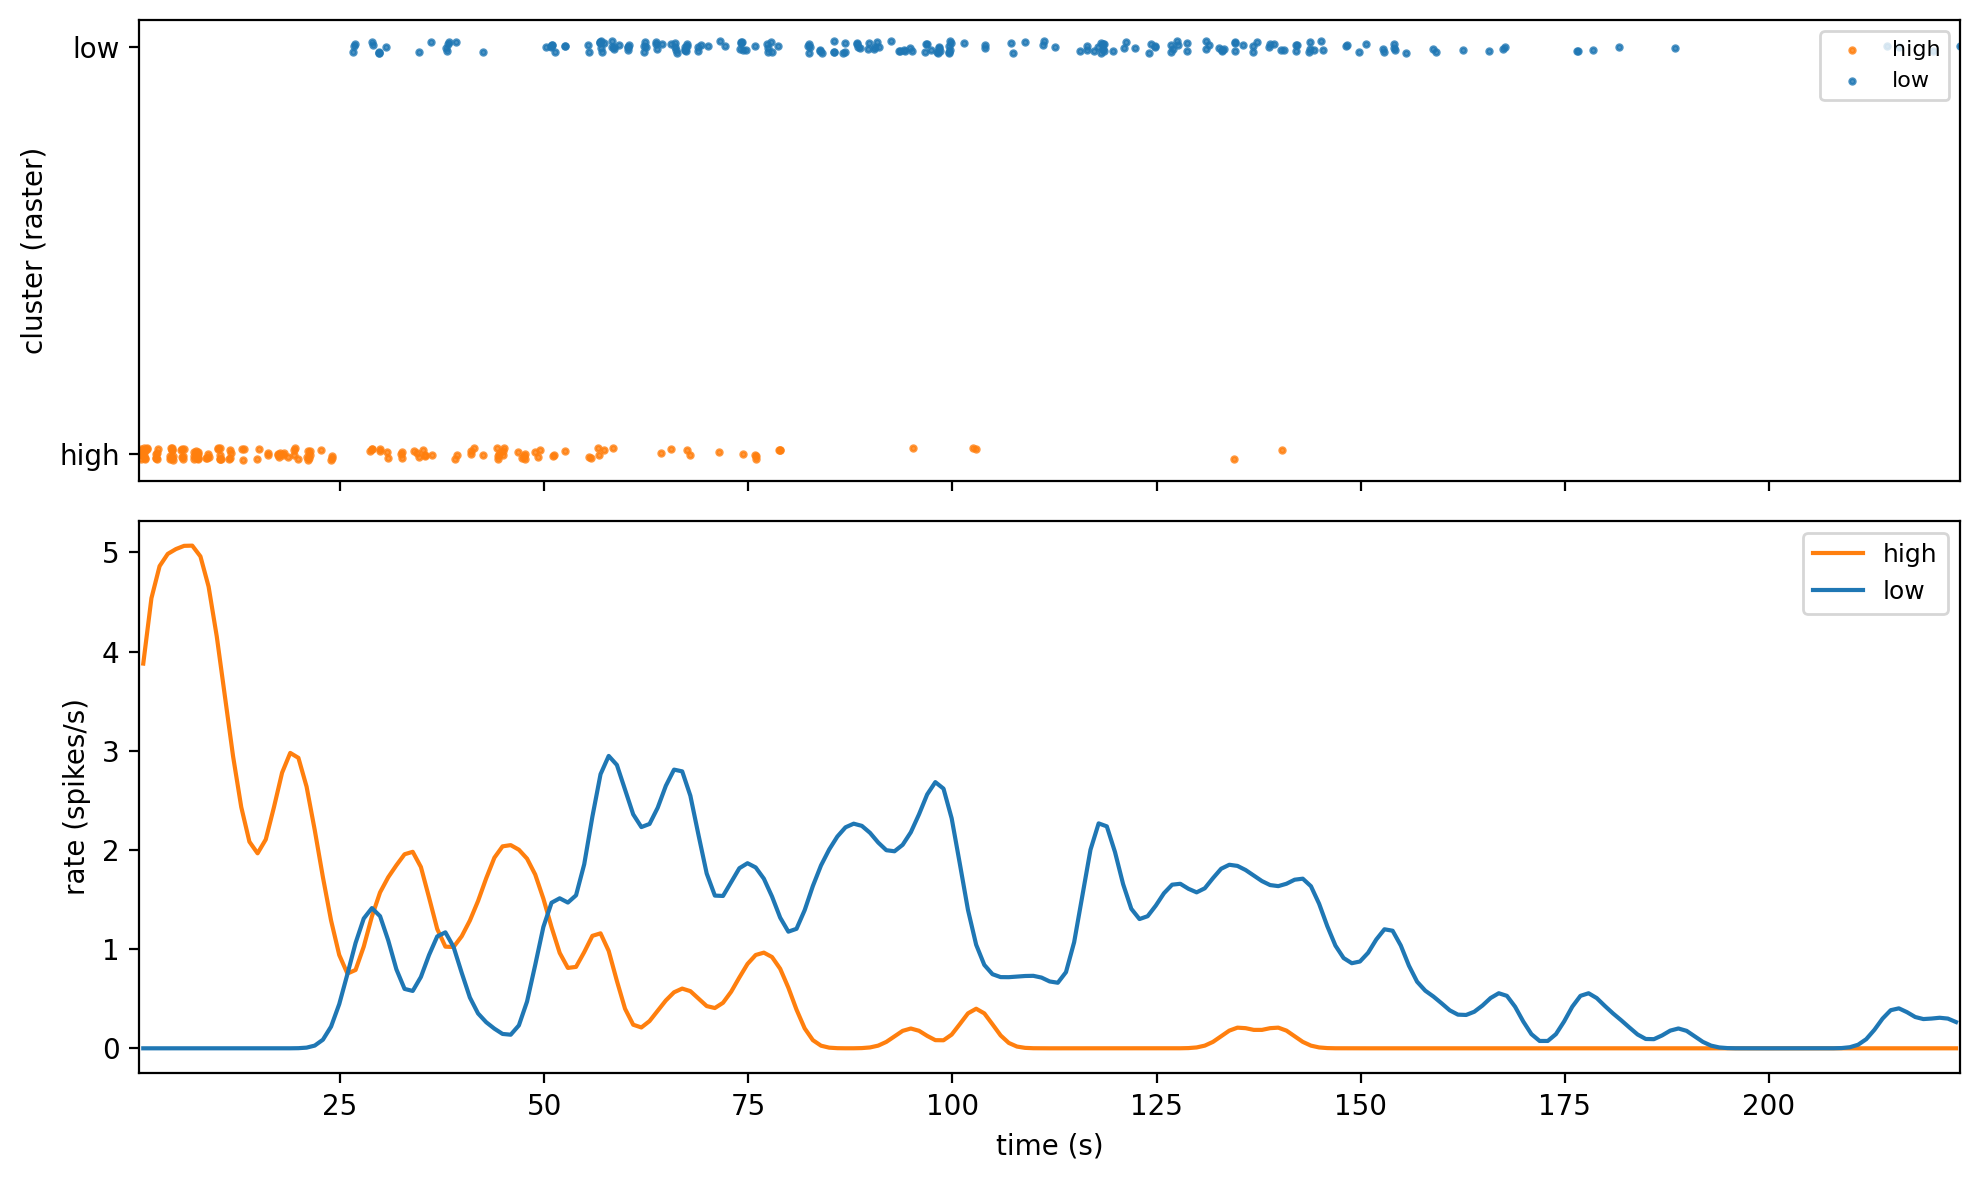

→ Computing cluster transition matrix


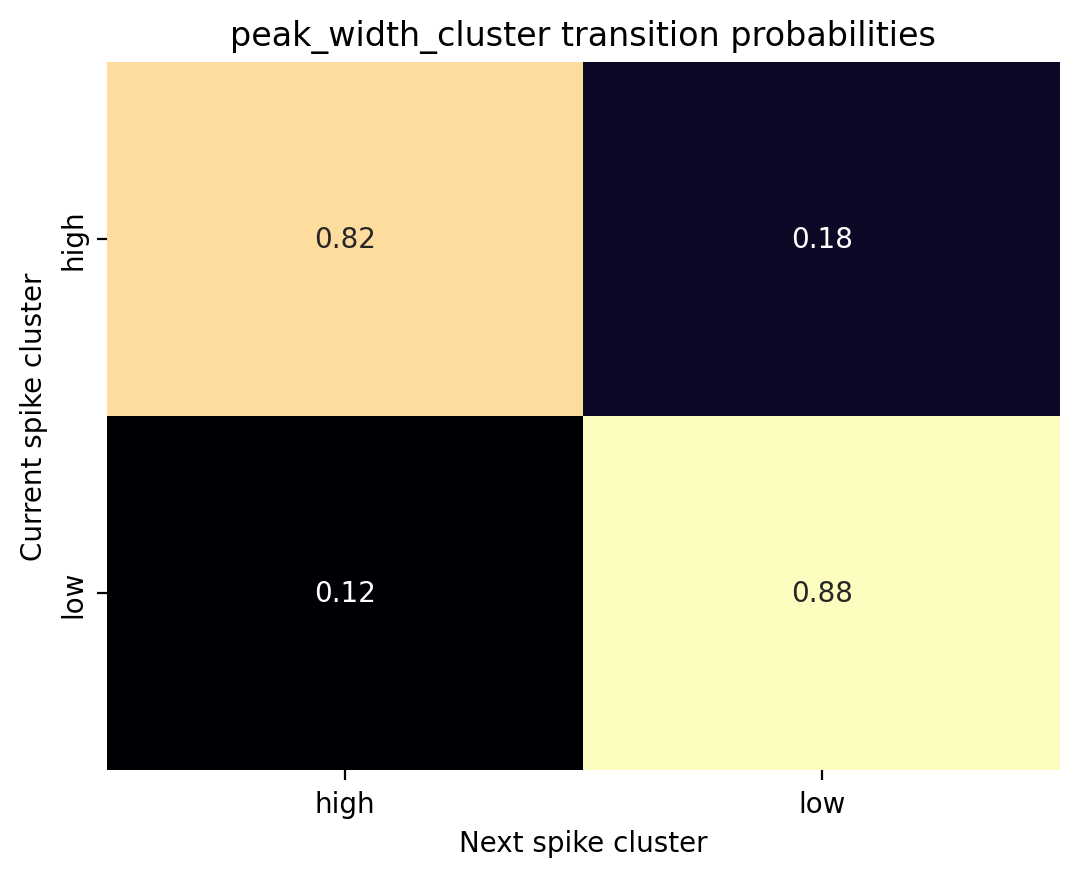

===== DONE =====


===== CLUSTER REPORT: exp_lambda_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


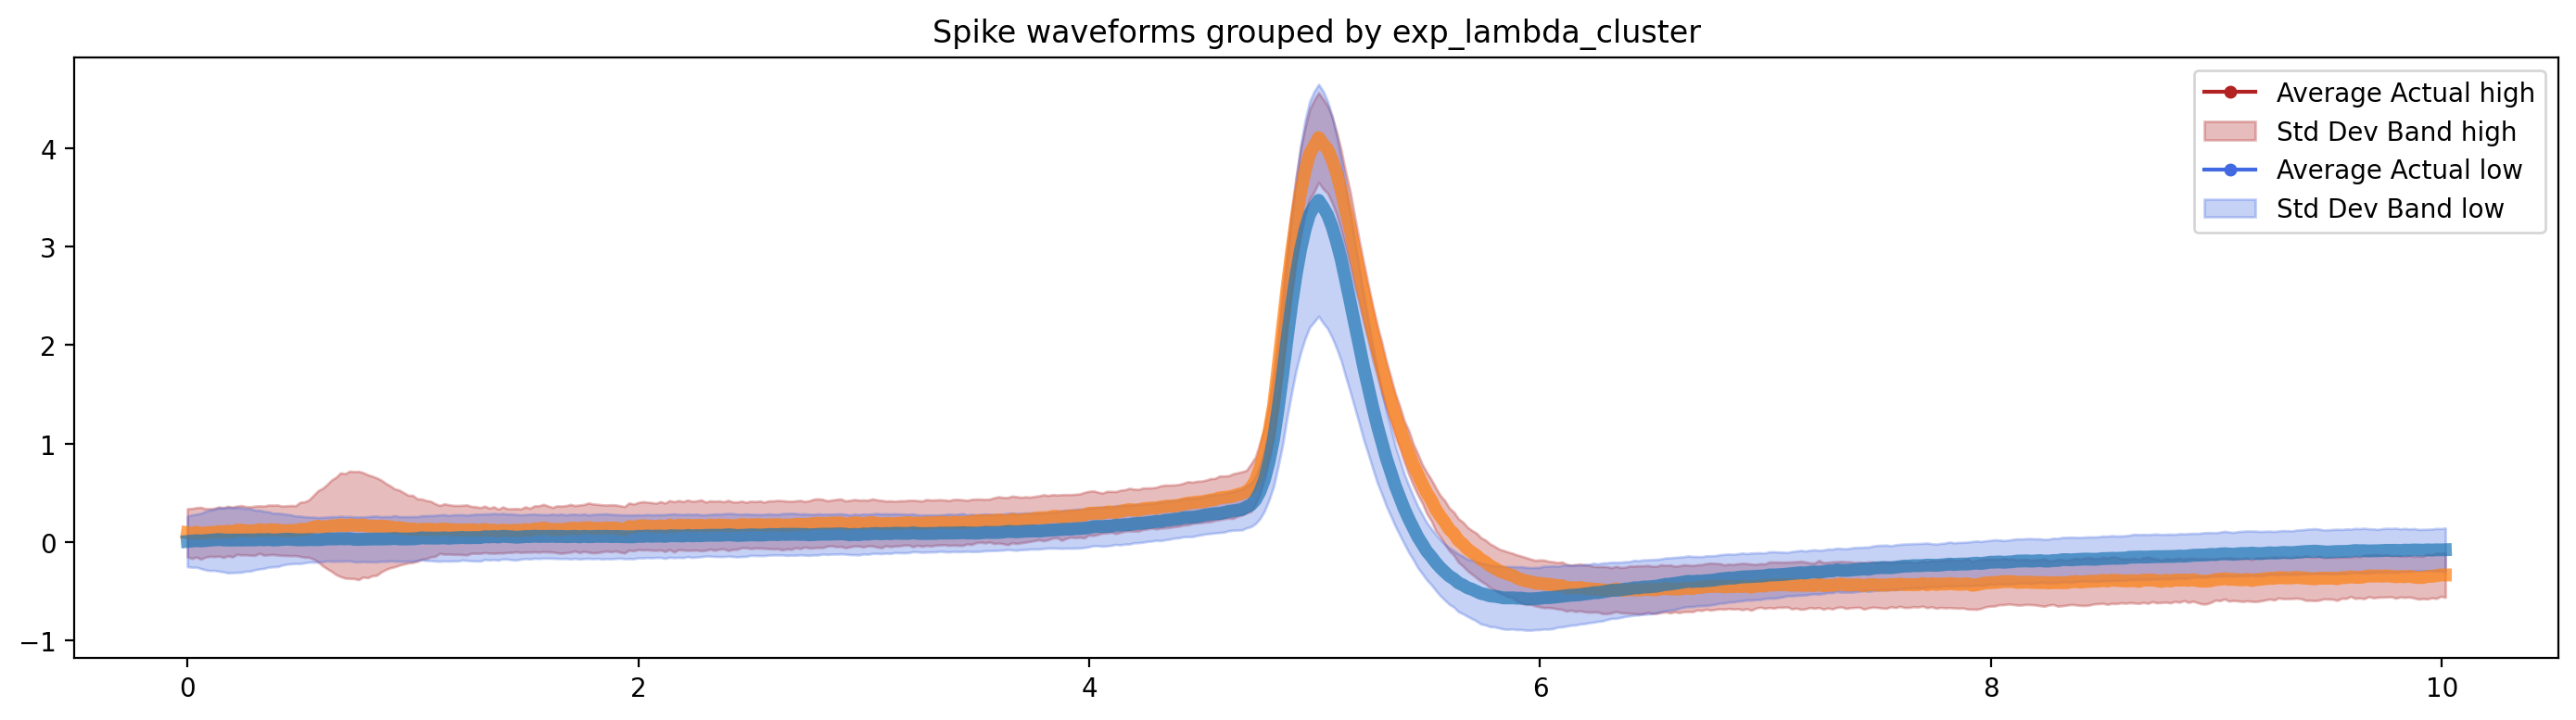

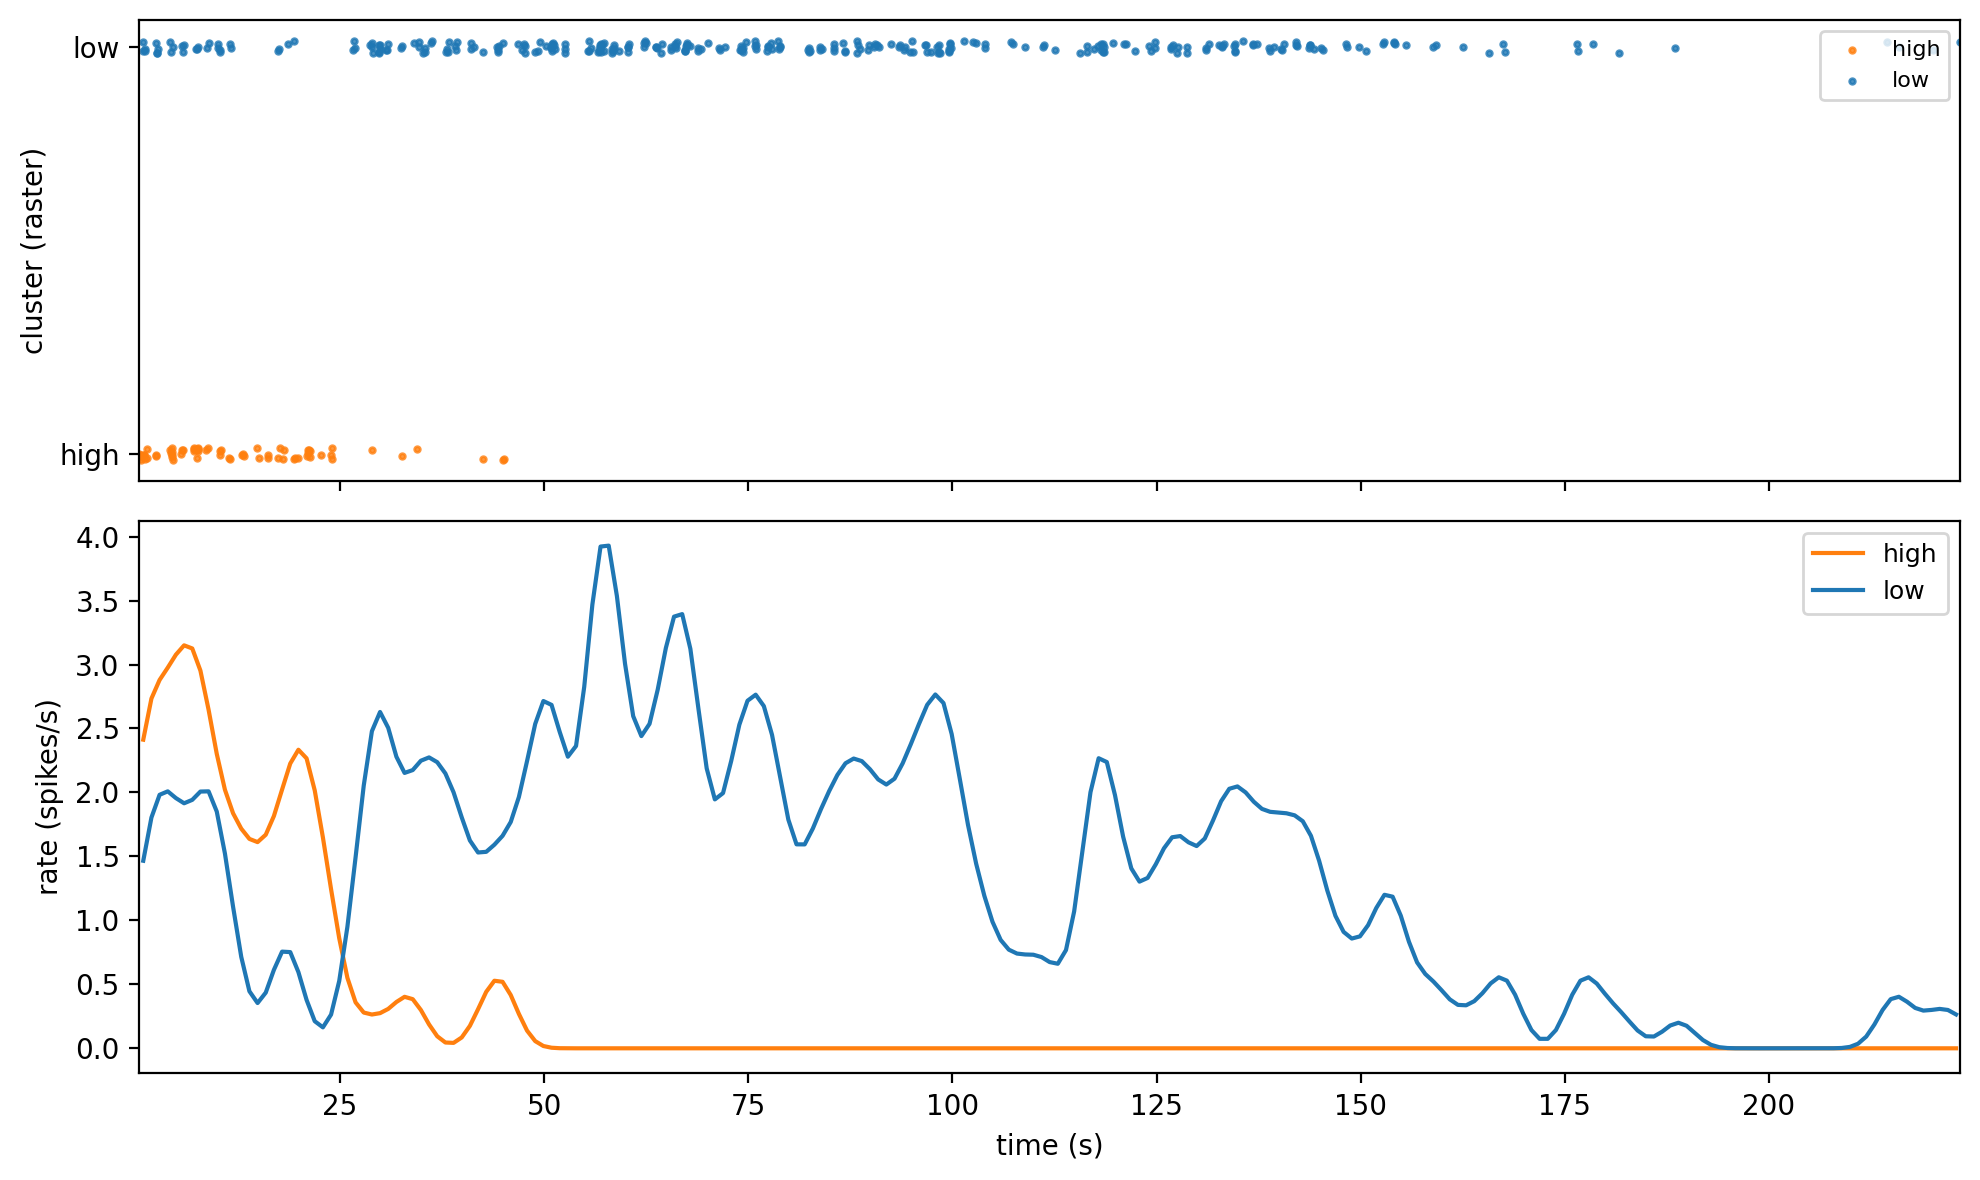

→ Computing cluster transition matrix


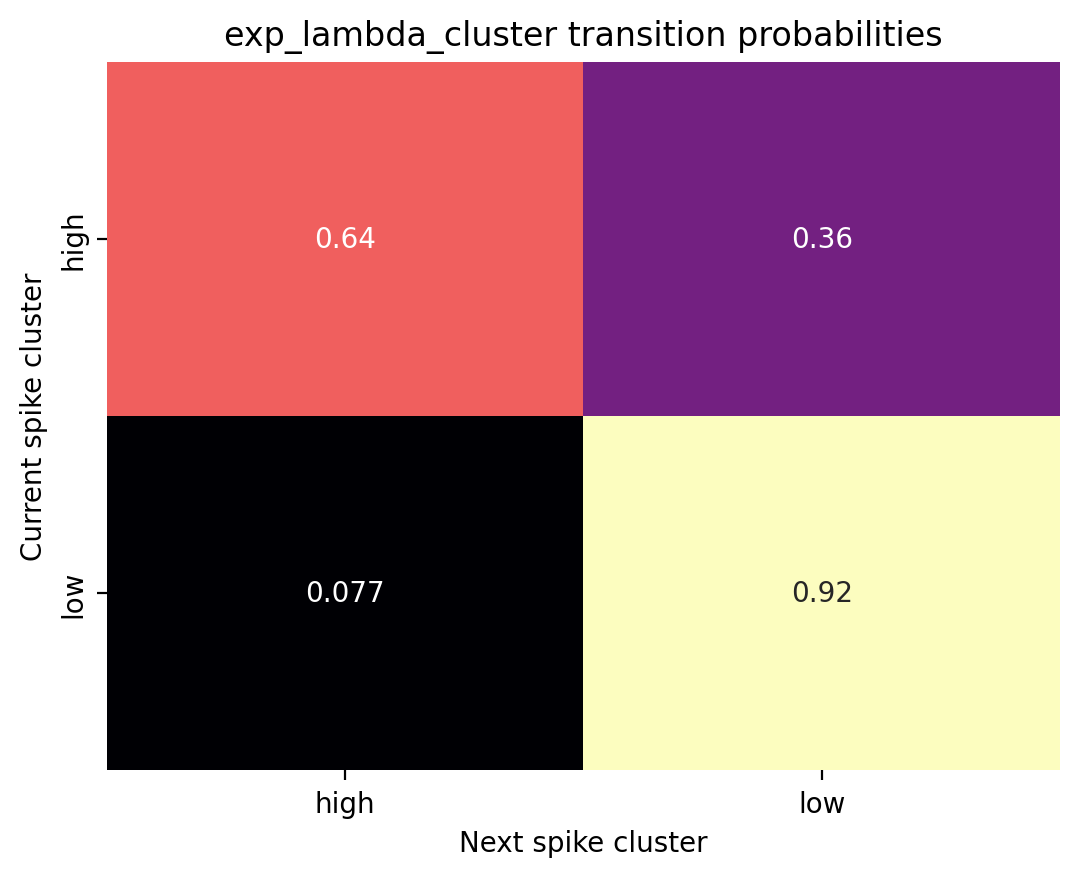

===== DONE =====


===== CLUSTER REPORT: log_isi_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


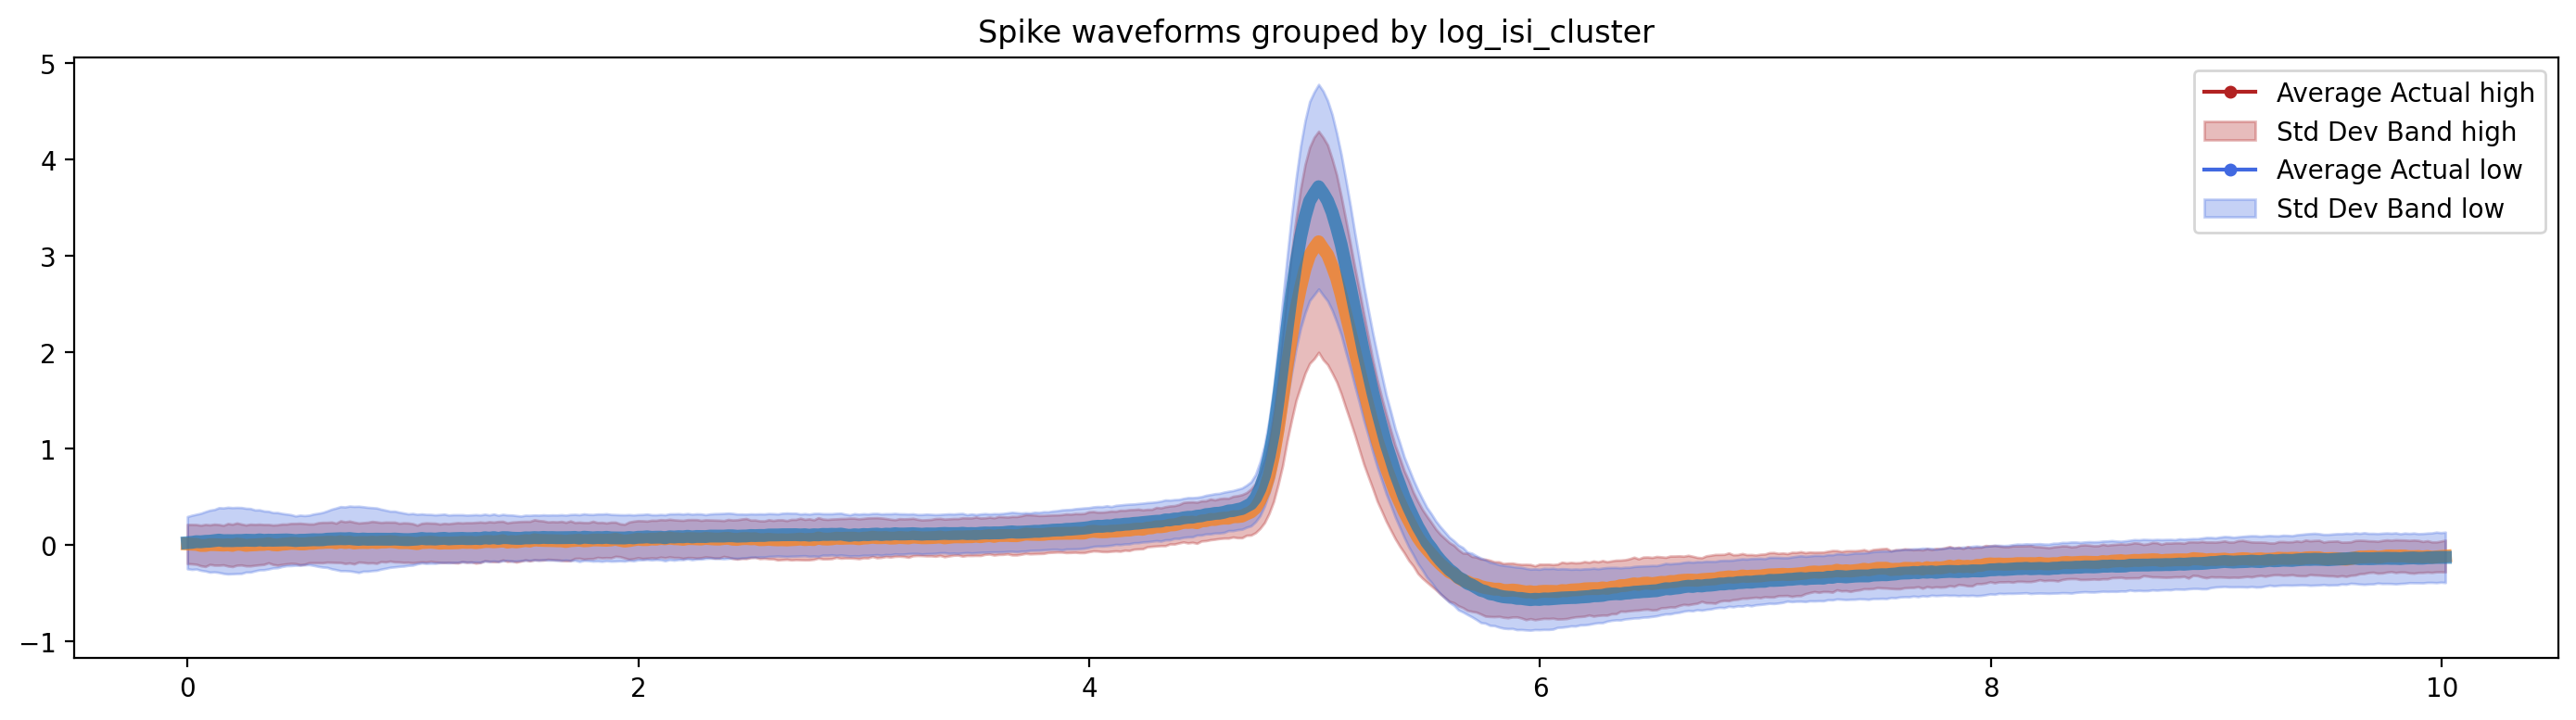

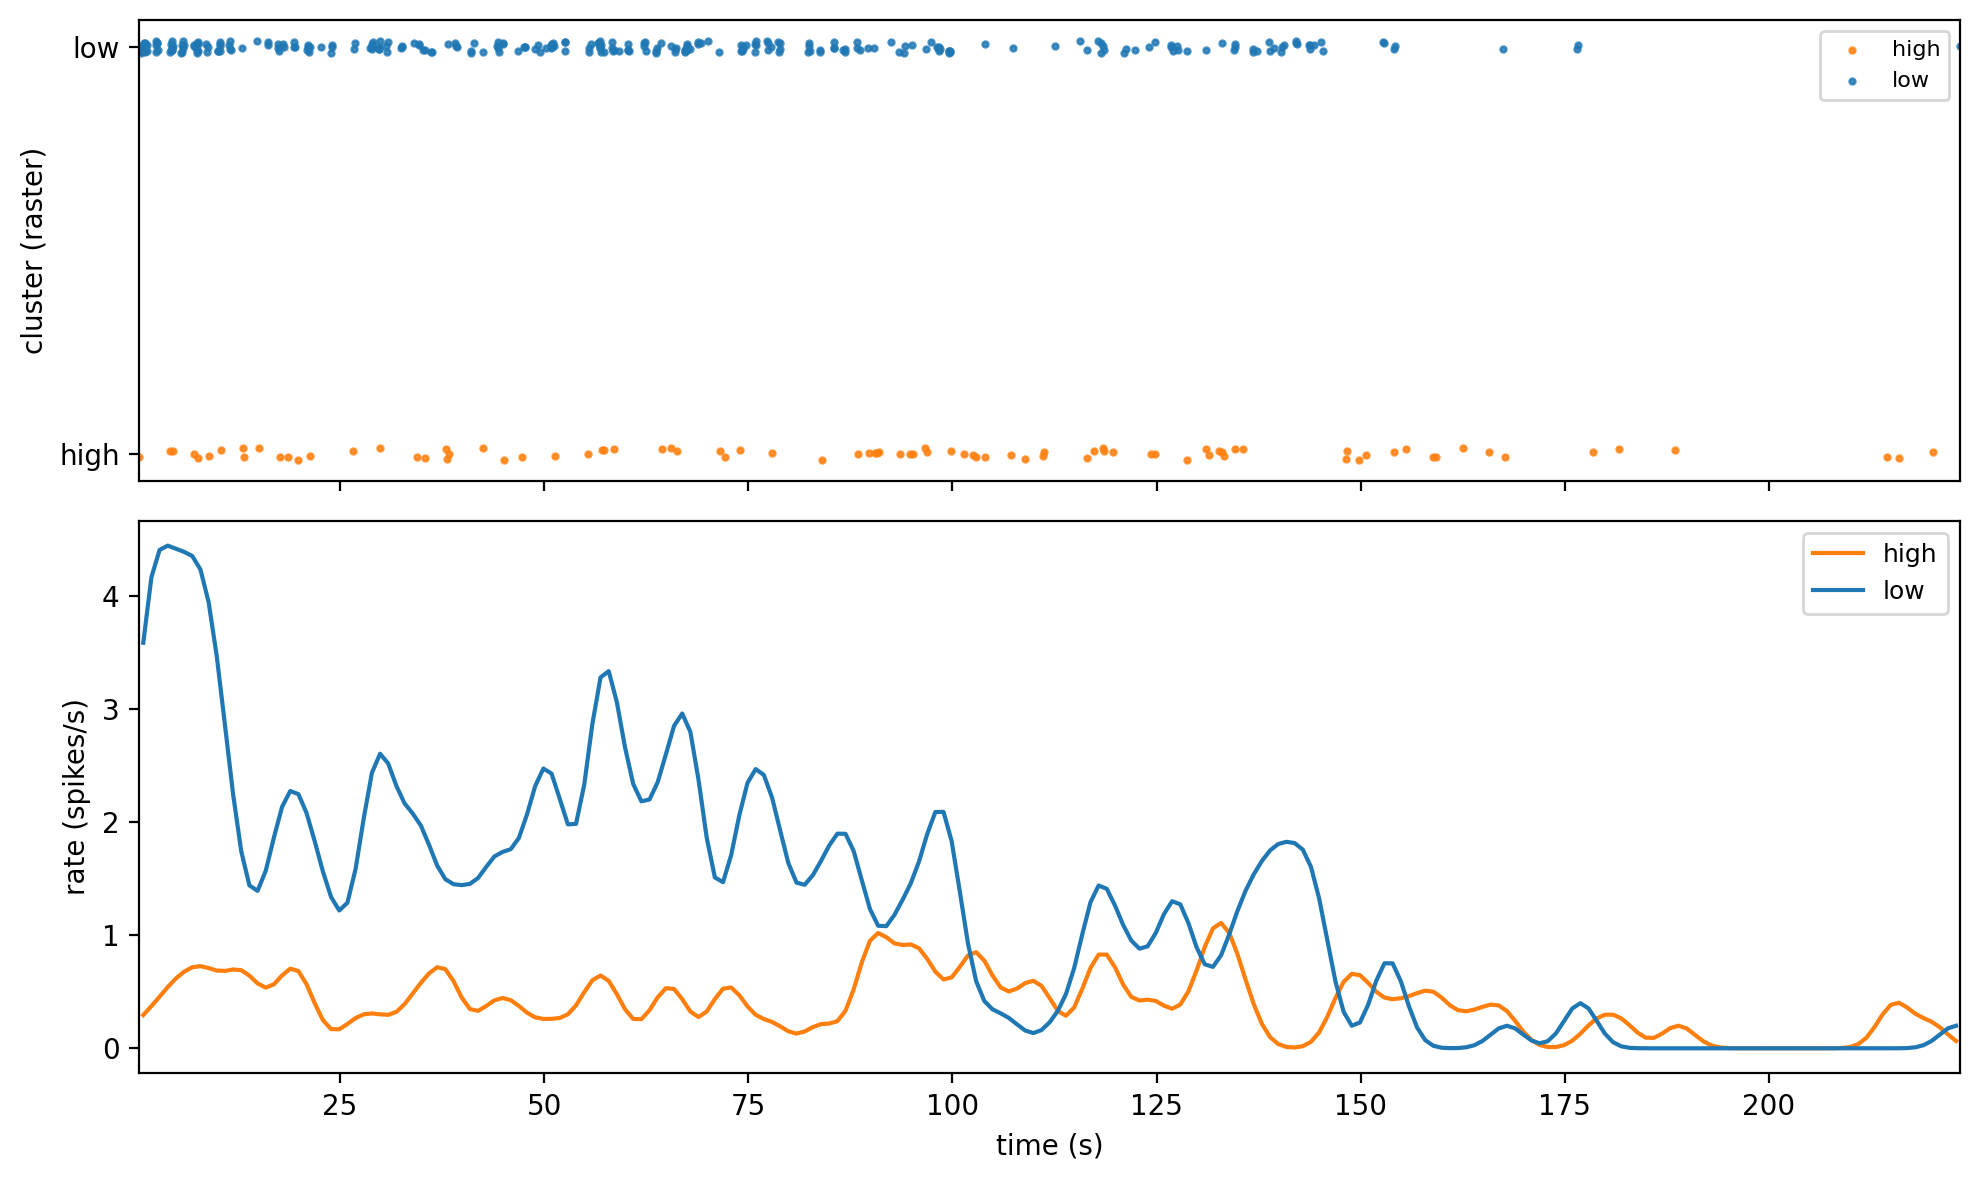

→ Computing cluster transition matrix


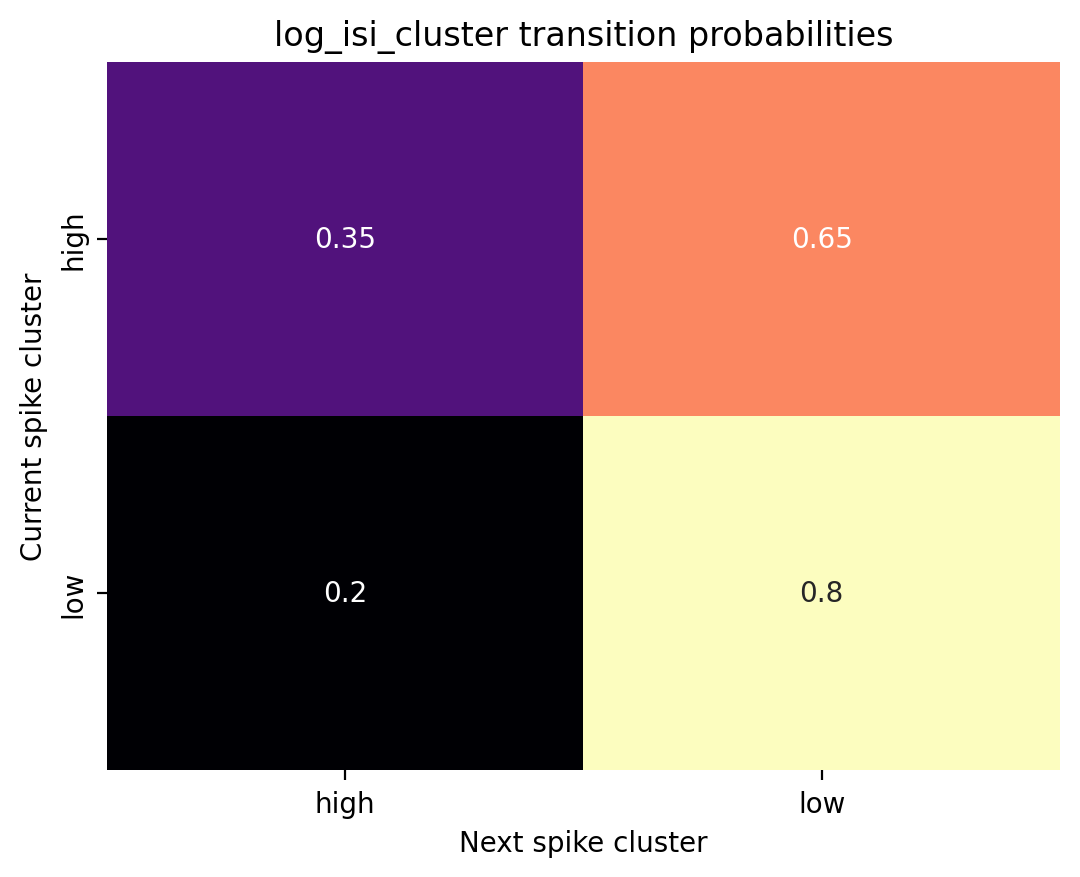

===== DONE =====



In [18]:
for col in df_features_clust.columns:
    if col.endswith("_cluster"):
        plot_full_cluster_report(df_features_clust, sp, col)



## STEP 3: LFP analysis

In [19]:
# Extract LFP windows for ALL spikes (no condition)
all_spike_extractor = extract_lfp_windows(
    spk_df=df_features_clust,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5,
    condition=None
)

windows_all      = all_spike_extractor["windows"]
t_rel_all        = all_spike_extractor["times_rel_ms"]
spike_times_all  = all_spike_extractor["spike_times_ms"]
next_spk_all     = all_spike_extractor["next_spike_times_ms"]
meta_df_all      = all_spike_extractor["meta_df"]


In [73]:
"""specparam_by_spike = run_time_resolved_specparam_per_spike(
    lfp_windows=windows_all,
    times_rel_list=t_rel_all,
    next_rel_list=next_spk_all,
    fs=lfp_fs,
    inner_window_sec=0.5,
    freq_range=(4, 90),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=10,
    aperiodic_mode="fixed")"""

Specparam per spike:   0%|          | 0/360 [00:00<?, ?it/s]

In [74]:
"""
#save as pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c1/specp_epochs.pkl', 'wb') as file:
    pickle.dump(specparam_by_spike, file)"""

In [75]:
#open pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c1/specp_epochs.pkl', 'rb') as file:
    time_res_results = pickle.load(file)

In [92]:
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)

#### Analyze by group

In [93]:
def build_lfp_groups_from_clusters(
    df_features,
    all_spike_extractor,
    cluster_cols=None,
):
    """
    Build LFP groups from cluster columns in df_features.

    Returns:
        groups : dict
            groups[group_name] = {
                "windows":   list[np.ndarray],
                "times_rel": list[np.ndarray],
                "next_rel":  np.ndarray,
                "spk_inds":  np.ndarray,
            }
    """

    windows_all     = all_spike_extractor["windows"]
    t_rel_all       = all_spike_extractor["times_rel_ms"]
    spike_times_all = np.asarray(all_spike_extractor["spike_times_ms"], float)
    next_spk_all    = np.asarray(all_spike_extractor["next_spike_times_ms"], float)
    meta_df_all     = all_spike_extractor["meta_df"]

    # Map spk_id → index in windows_all
    spk_id_to_win = {
        sid: i for i, sid in enumerate(meta_df_all["spk_id"].values)
    }

    if cluster_cols is None:
        cluster_cols = [c for c in df_features.columns if c.endswith("_cluster")]

    groups = {}

    for col in cluster_cols:
        for label in df_features[col].dropna().unique():

            # spike IDs belonging to this cluster
            spk_ids = df_features.loc[df_features[col] == label, "spk_id"].values

            # map to window indices (only keep ones that exist)
            win_inds = [
                spk_id_to_win[sid]
                for sid in spk_ids
                if sid in spk_id_to_win
            ]

            if len(win_inds) == 0:
                continue

            group_name = f"{col}: {label}"

            groups[group_name] = {
                "windows":   [windows_all[i] for i in win_inds],
                "times_rel": [t_rel_all[i]   for i in win_inds],
                "next_rel":  next_spk_all[win_inds] - spike_times_all[win_inds],
                "spk_inds":  np.asarray(win_inds, dtype=int),
            }

    return groups


In [94]:
groups = build_lfp_groups_from_clusters(df_features_clust
    ,all_spike_extractor)

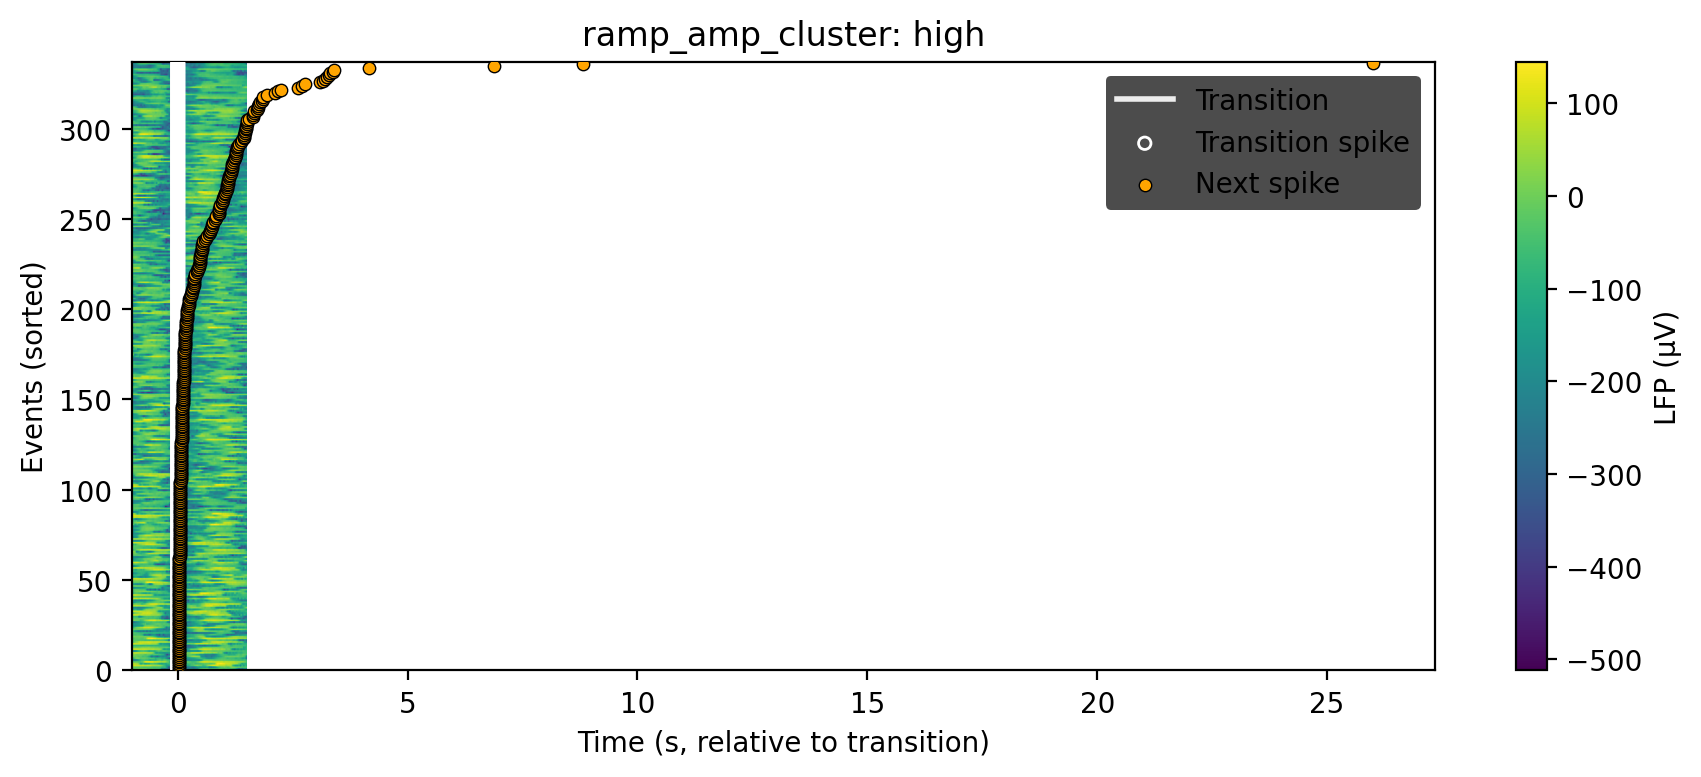

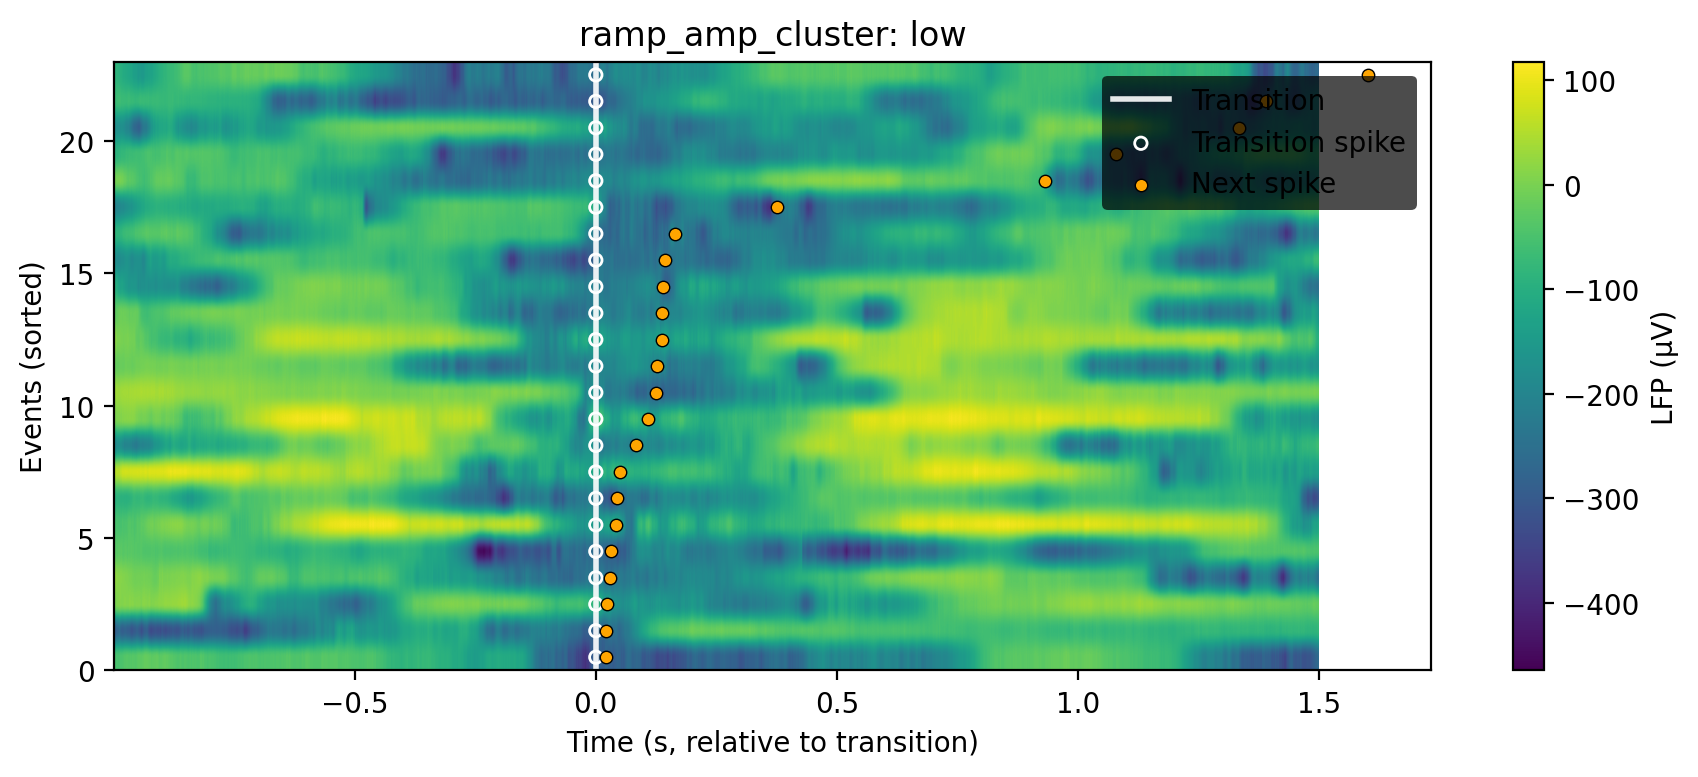

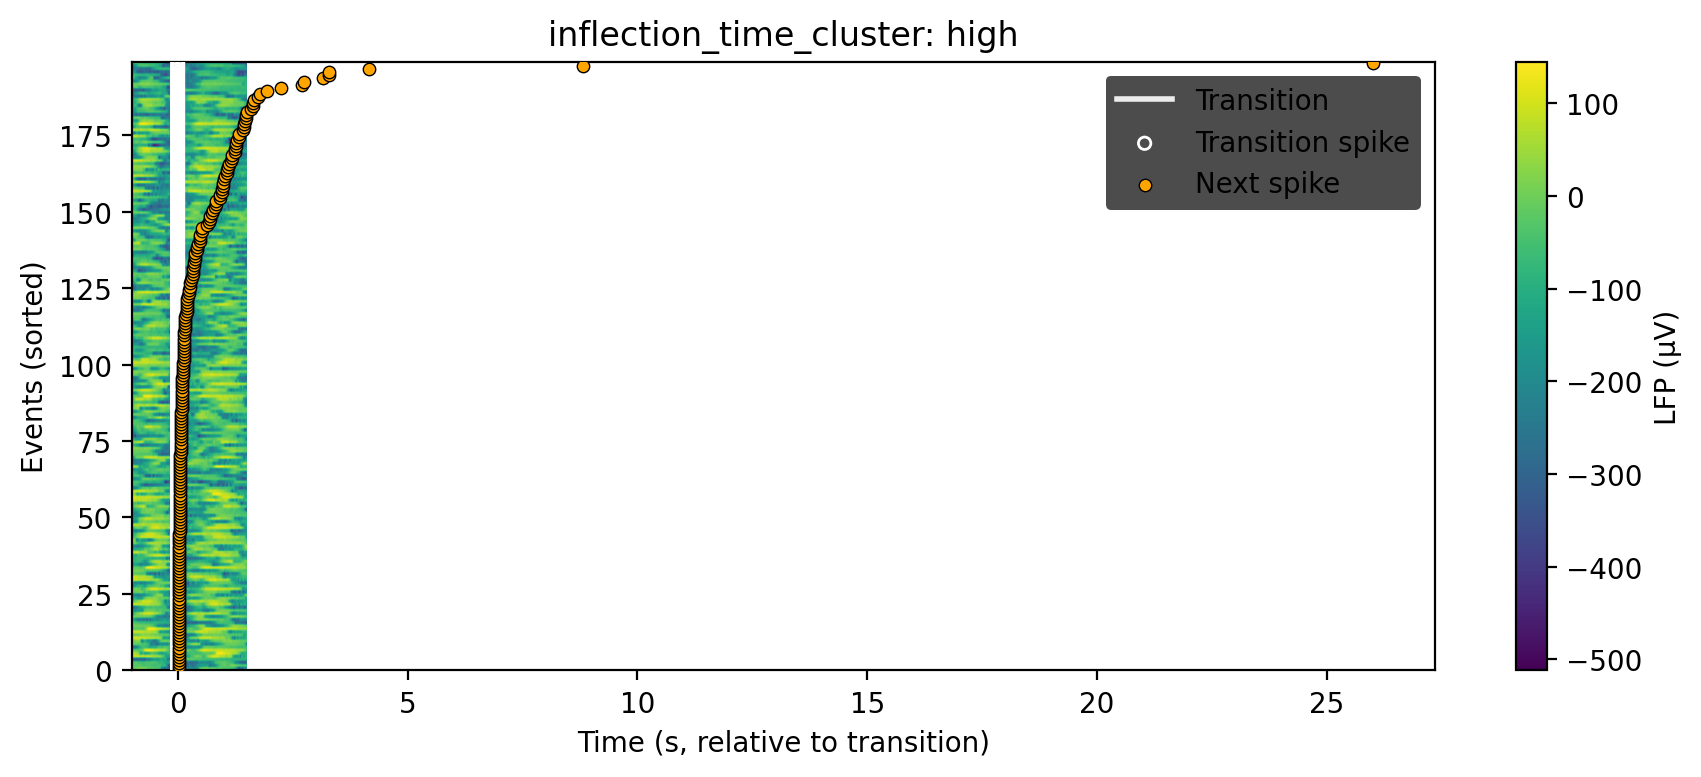

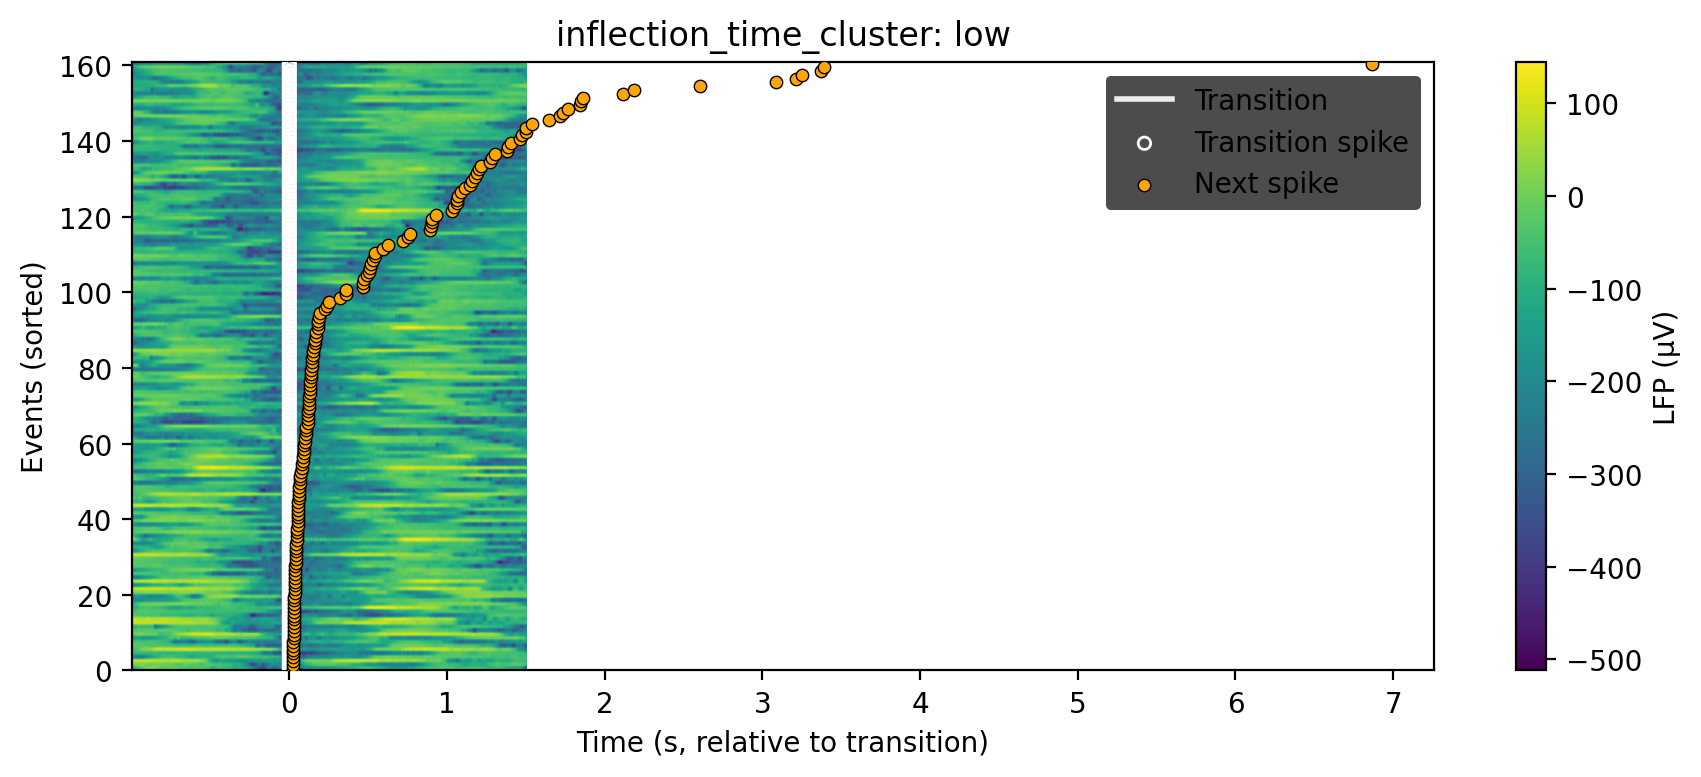

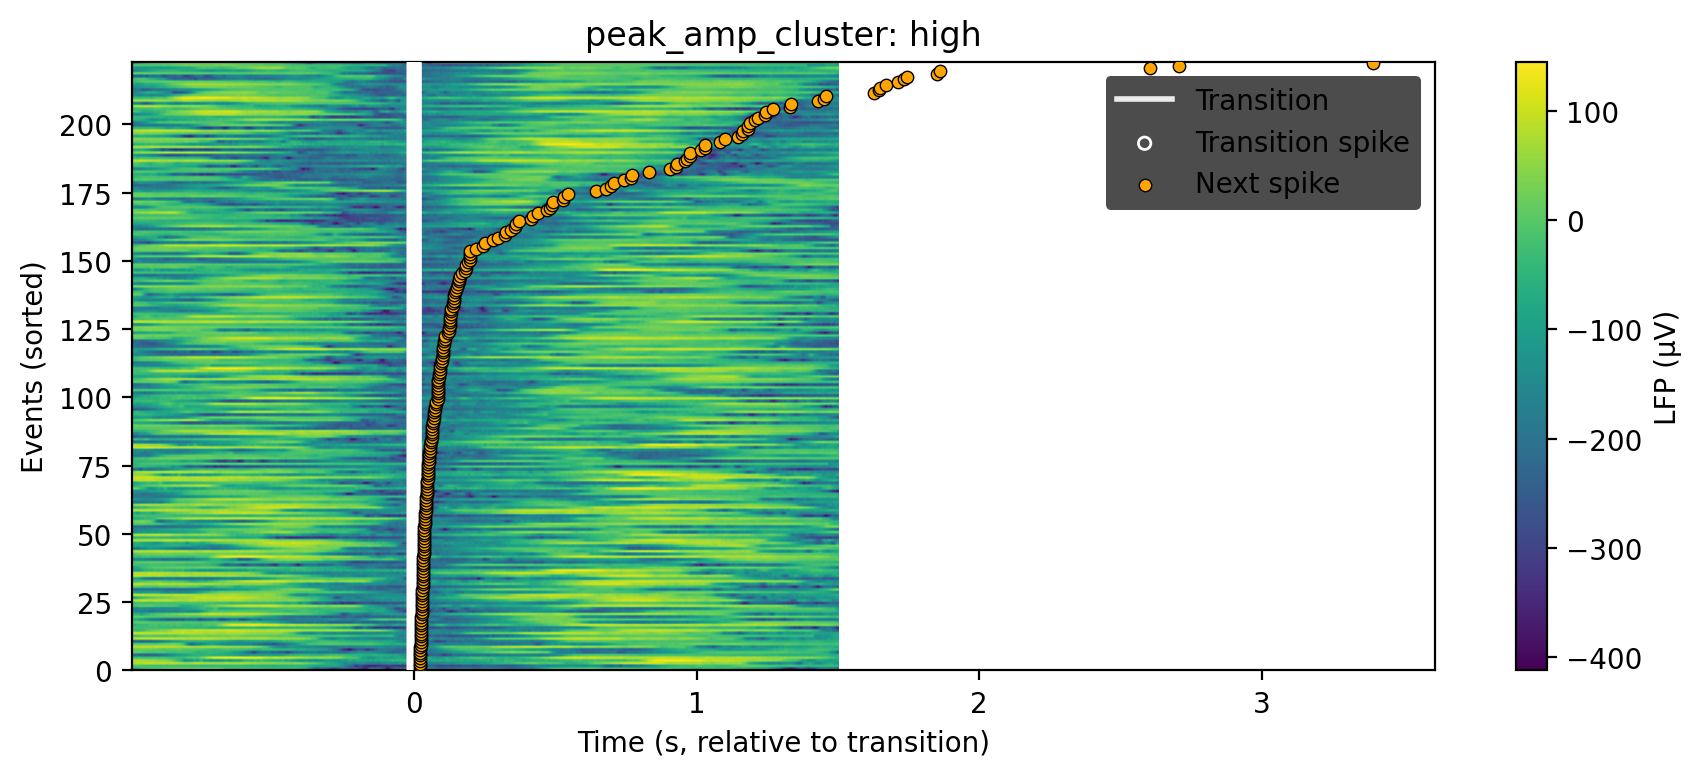

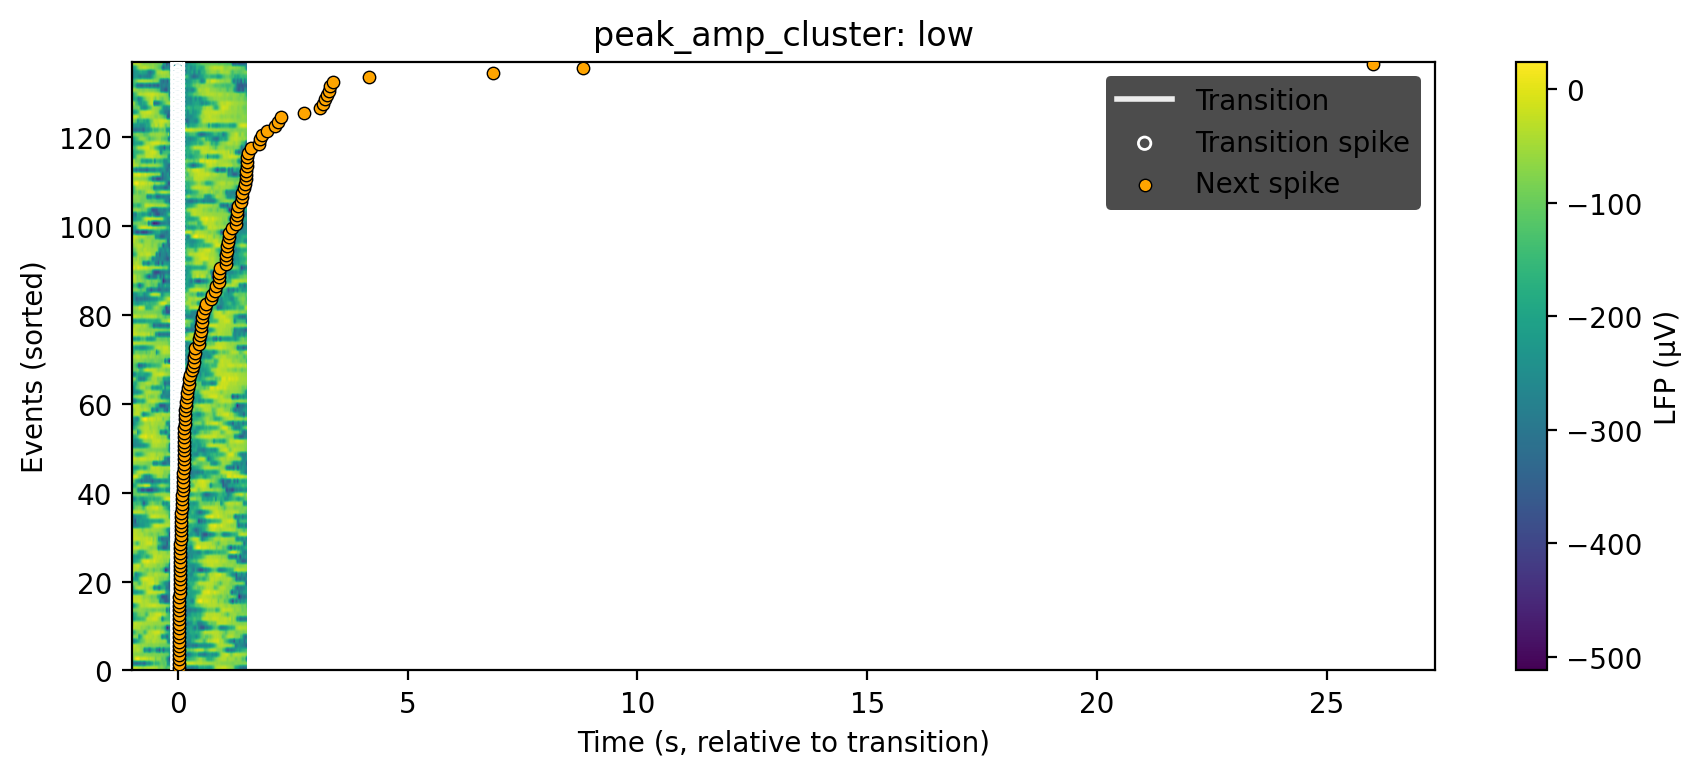

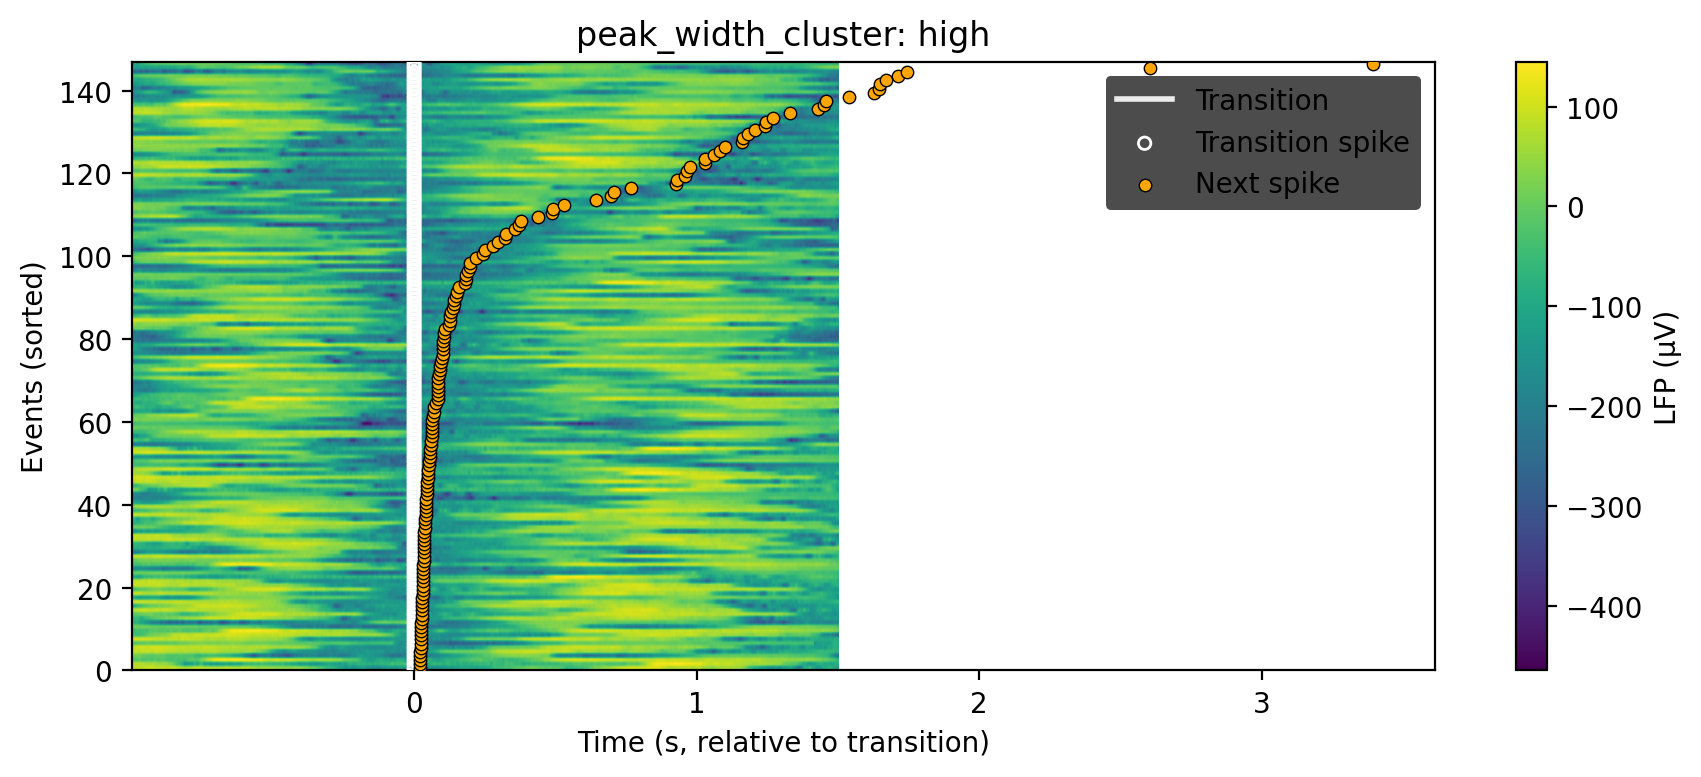

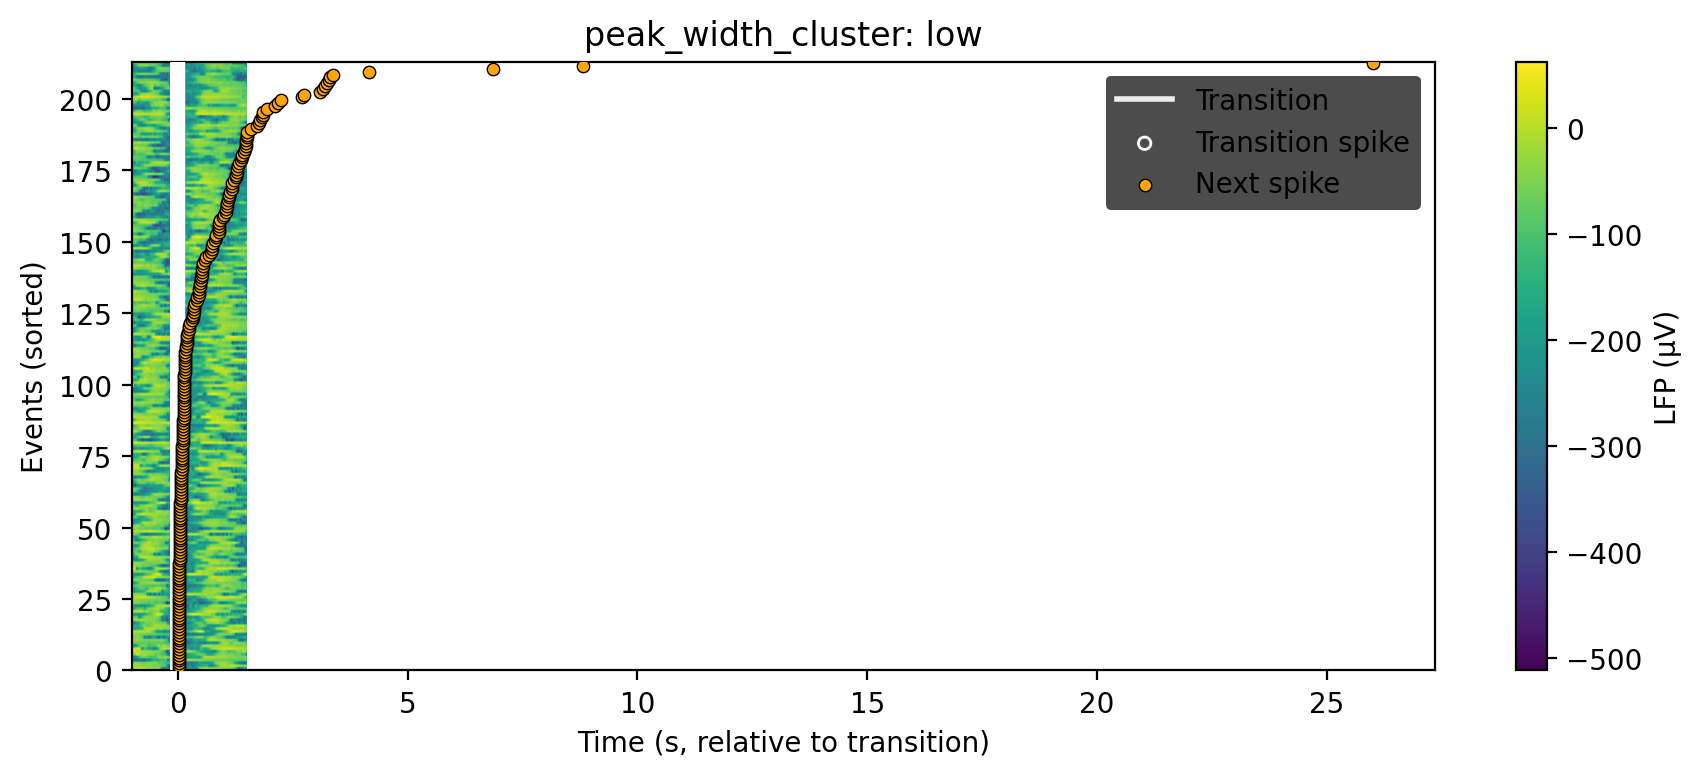

In [ ]:
lfp_heatmaps = plot_window_feature_groups_heatmap(
    groups,
    feature_label="LFP (µV)",
    cmap="viridis",
    time_unit="ms",
)


In [ ]:
#plot mean LFP around spike 
fig, ax, out_traces = plot_window_feature_group_traces(
    groups,
    time_unit="ms",             # if your t_rel_* are already in seconds
    ylabel="LFP (µV)",
    title="Average LFP around spikes (all groups)",
    band_k=1.0,                # 1×STD band
)


In [ ]:
def make_specparam_feature_groups(
    specparam_by_spike,
    groups,
    feature: str,
    band: str = None,
    next_rel_unit: str = "ms",   # groups['next_rel'] is in ms in your current code
):
    """
    Build a groups-style dict (windows/times_rel/next_rel) for specparam features,
    using specparam_by_spike (computed once per spike) and groups (which store spk_inds).

    Returns:
        feat_groups[gname] = {
            "windows":   list of 1D arrays (feature over epochs),
            "times_rel": list of 1D arrays (epoch times, seconds),
            "next_rel":  1D array (seconds),
            "spk_inds":  np.ndarray,
        }
    """
    out = {}

    for gname, gdict in groups.items():
        spk_inds = np.asarray(gdict.get("spk_inds", []), dtype=int)
        if spk_inds.size == 0:
            continue

        win_list = []
        t_list   = []
        next_list = []

        # next_rel for these events (convert to seconds)
        next_rel = np.asarray(gdict.get("next_rel", np.full(spk_inds.size, np.nan)), float)
        if next_rel_unit == "ms":
            next_rel_s = next_rel / 1000.0
        else:
            next_rel_s = next_rel

        # collect per-spike traces
        for k, ind in enumerate(spk_inds):
            if ind < 0 or ind >= len(specparam_by_spike):
                continue

            res = specparam_by_spike[ind]
            if res is None:
                continue

            t_bins_s = np.asarray(res.get("t_bins_s", []), float)
            if t_bins_s.size == 0:
                continue

            if feature in ["offset", "exponent", "r_squared", "knee"]:
                arr = res.get(feature, None)
            elif feature == "band":
                if band is None:
                    raise ValueError("feature='band' requires band='gamma'/'alpha'/etc.")
                arr = res.get("band_aucs", {}).get(band, None)
            else:
                raise ValueError(f"Unknown feature: {feature}")

            if arr is None:
                continue

            arr = np.asarray(arr, float)
            if arr.size != t_bins_s.size:
                continue

            win_list.append(arr)
            t_list.append(t_bins_s)
            next_list.append(next_rel_s[k])

        if len(win_list) == 0:
            continue

        out[gname] = {
            "windows":   win_list,
            "times_rel": t_list,                       # seconds
            "next_rel":  np.asarray(next_list, float), # seconds
            "spk_inds":  spk_inds,
        }

    return out



In [ ]:
gamma_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="band", band="gamma"
)

exp_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="exponent"
)


In [ ]:
OUT = plot_window_feature_groups_heatmap(
    gamma_groups,
    feature_label="Gamma AUC",
    cmap="viridis",
    time_unit="s",      # IMPORTANT: specparam times are seconds
    sort_by="next_rel",
)

OUT = plot_window_feature_groups_heatmap(
    exp_groups,
    feature_label="Aperiodic exponent",
    cmap="viridis",
    time_unit="s",
    sort_by="next_rel",
)


In [ ]:
def plot_window_feature_group_traces_ci_delta(
    feat_groups,
    time_unit="s",
    ylabel="Δ Value",
    title=None,
    baseline_window=(-0.3, -0.05),
    alpha_ci=0.25,
):
    """
    Plot mean ± 95% CI of baseline-corrected (Δ) feature traces.
    Baseline is computed per epoch.
    """

    fig, ax = plt.subplots(figsize=(12
                                , 4))

    for gname, g in feat_groups.items():

        windows   = g["windows"]
        times_rel = g["times_rel"]
        color     = g.get("color", None)

        # --- determine common time grid ---
        base_T = None
        for t in times_rel:
            if len(t) > 1:
                base_T = np.asarray(t, float)
                break
        if base_T is None:
            continue

        Tgrid = base_T / 1000.0 if time_unit == "ms" else base_T.copy()

        mats = []

        for w, t in zip(windows, times_rel):
            w = np.asarray(w, float)
            t = np.asarray(t, float)

            if w.size != t.size or w.size < 2:
                continue

            t_sec = t / 1000.0 if time_unit == "ms" else t

            # ---- BASELINE SUBTRACTION (PER EPOCH) ----
            b0, b1 = baseline_window
            bmask = (t_sec >= b0) & (t_sec <= b1)

            if not np.any(bmask):
                continue

            baseline = np.nanmean(w[bmask])
            w = w - baseline

            # ---- interpolate onto common grid ----
            yi = np.full_like(Tgrid, np.nan)
            inside = (Tgrid >= t_sec[0]) & (Tgrid <= t_sec[-1])

            if inside.any():
                yi[inside] = np.interp(Tgrid[inside], t_sec, w)
                mats.append(yi)

        if len(mats) < 2:
            continue

        A = np.vstack(mats)
        mean = np.nanmean(A, axis=0)
        std  = np.nanstd(A, axis=0)
        n    = np.sum(np.isfinite(A), axis=0)

        ci95 = 1.96 * std / np.sqrt(n)

        ax.plot(Tgrid, mean, label=gname, color=color)
        ax.fill_between(
            Tgrid,
            mean - ci95,
            mean + ci95,
            color=color,
            alpha=alpha_ci,
            linewidth=0,
        )

    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("Time (s, relative to spike)")
    ax.set_ylabel(ylabel)

    if title:
        ax.set_title(title)

    ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

    fig.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on the right
    plt.show()


    return fig, ax


In [ ]:
plot_window_feature_group_traces_ci_delta(
    gamma_groups,
    ylabel="Δ Gamma AUC",
    title="Δ Gamma AUC (baseline-corrected, mean ± 95% CI)",
    baseline_window=(-0.3, -0.05),
)
